# LiH fermionic-term noncommutation graph workflow

## Purpose

This notebook constructs a LiH fermionic Hamiltonian, groups raw OpenFermion monomials into Hermitian fermionic Hamiltonian terms, builds the fermionic noncommutation graph, colors the graph into commuting groups, and maps the same fermionic terms into Jordan-Wigner (JW) and Bravyi-Kitaev (BK) qubit operators.

The workflow is the LiH version of the H2 notebook. The main difference is that LiH/STO-3G is larger than H2/STO-3G. To keep the graph construction manageable, the default configuration uses a common active-space setup:

- freeze the lowest Li core spatial orbital: `occupied_indices = [0]`
- keep active spatial orbitals: `active_indices = [1, 2, 3]`

Set `USE_ACTIVE_SPACE = False` in Cell 1 to build the full LiH/STO-3G Hamiltonian. The full graph may be significantly larger.

## Main definitions

The fermionic Hamiltonian is written as

$$
H_f = \sum_i T_i.
$$

Each graph vertex is a Hermitian fermionic Hamiltonian term. If a raw monomial is not self-adjoint, it is grouped as

$$
T_i = c_i O_i + c_i^* O_i^\dagger.
$$

If the monomial is already self-adjoint, for example a number operator or density-density operator, it is kept once:

$$
T_i = c_i O_i.
$$

The graph is a noncommutation graph:

$$
(T_i,T_j) \in E \quad \Longleftrightarrow \quad [T_i,T_j] \neq 0.
$$

Therefore, a graph coloring of this noncommutation graph partitions the Hamiltonian into internally commuting blocks:

$$
H_f = H_{red} + H_{blue} + \cdots,
\qquad
H_c = \sum_{T_i \in c} T_i.
$$

Terms inside the same color commute and can be reordered freely within a first-order Trotter block. Different color blocks generally do not commute, so block ordering can affect Trotter error.

## Code organization

### Cell 1
Builds the LiH fermionic Hamiltonian and stores Hermitian fermionic terms in `hermitian_terms`.

### Cell 2
Builds the noncommutation graph `G`, where each vertex is a fermionic term `T_i` and each edge is a nonzero fermionic commutator.

### Cell 3
Colors the graph into commuting groups, forms color-block Hamiltonians, optionally ranks block orders by a leading-commutator proxy, maps each fermionic term and block into JW and BK, and verifies that terms inside each color group commute after JW/BK mapping.

## Important interpretation

JW and BK should be applied to the same fermionic source terms:

$$
T_i \mapsto JW(T_i),
\qquad
T_i \mapsto BK(T_i).
$$

The Pauli strings produced by JW and BK can differ, but they represent the same original fermionic operator. If two fermionic terms commute, their full mapped JW operators commute, and their full mapped BK operators also commute. A single fermionic term may map to a sum of Pauli strings, so the statement is about the full mapped operator, not necessarily every individual Pauli string in the expansion.


In [26]:
# Cell 1: Build LiH fermionic Hamiltonian and Hermitian fermionic terms

import pandas as pd

from openfermion.chem import MolecularData
from openfermion.ops import FermionOperator
from openfermion.transforms import get_fermion_operator, normal_ordered
from openfermion.utils import hermitian_conjugated
from openfermionpyscf import run_pyscf

pd.set_option("display.max_colwidth", None)


# ------------------------------------------------------------
# LiH configuration
# ------------------------------------------------------------

LIH_BOND_LENGTH = 1.45  # Angstrom
BASIS = "sto-3g"
MULTIPLICITY = 1
CHARGE = 0

# Recommended default for a manageable LiH graph:
# freeze Li core spatial orbital 0 and keep active orbitals 1, 2, 3.
USE_ACTIVE_SPACE = True
OCCUPIED_INDICES = [0]
ACTIVE_INDICES = [1, 2, 3]

# Set this smaller, e.g. 1e-10, if tiny numerical terms clutter the graph.
TERM_ABS_TOL = 1e-12


def format_fermion_term(term):
    if term == ():
        return "I"

    pieces = []
    for orbital, action in term:
        if action == 1:
            pieces.append(f"a_{orbital}^dagger")
        else:
            pieces.append(f"a_{orbital}")
    return " ".join(pieces)


def sort_fermion_key(term):
    return (len(term), term)


def coeff_to_str(c, digits=8):
    c = complex(c)
    if abs(c.imag) < 1e-12:
        return f"{c.real:+.{digits}f}"
    return f"{c.real:+.{digits}f}{c.imag:+.{digits}f}j"


def operator_to_string(op, digits=8):
    pieces = []

    for term, coeff in sorted(op.terms.items(), key=lambda item: sort_fermion_key(item[0])):
        pieces.append(f"{coeff_to_str(coeff, digits)} {format_fermion_term(term)}")

    if len(pieces) == 0:
        return "0"

    return " + ".join(pieces)


def dagger_term_key(term):
    """
    Return the OpenFermion key for O^dagger, where O is one monomial.
    """
    O = FermionOperator(term, 1.0)
    O_dag = normal_ordered(hermitian_conjugated(O))
    O_dag.compress(abs_tol=TERM_ABS_TOL)

    if len(O_dag.terms) != 1:
        raise ValueError(f"Expected one dagger term, got: {O_dag}")

    return next(iter(O_dag.terms.keys()))


def make_hermitian_fermionic_terms(fermion_hamiltonian, tol=TERM_ABS_TOL):
    """
    Group raw monomials into Hermitian fermionic Hamiltonian terms.

    If O is self-adjoint, keep c O.
    If O is not self-adjoint, group c O + c* O^dagger using the
    coefficients already present in the Hamiltonian.
    """
    used = set()
    hermitian_terms = []

    for term, coeff in fermion_hamiltonian.terms.items():
        if term in used:
            continue

        dag = dagger_term_key(term)

        if dag == term:
            T = FermionOperator(term, coeff)
            used.add(term)
        else:
            dag_coeff = fermion_hamiltonian.terms.get(dag, 0.0)

            T = FermionOperator(term, coeff)
            T += FermionOperator(dag, dag_coeff)

            used.add(term)
            used.add(dag)

        T = normal_ordered(T)
        T.compress(abs_tol=tol)
        hermitian_terms.append(T)

    return hermitian_terms


def infer_n_qubits_from_fermion_operator(op):
    """
    Infer the number of spin orbitals used by the FermionOperator.
    This is important for active-space Hamiltonians, where the active
    modes may be reindexed and smaller than molecule.n_qubits.
    """
    max_orbital = -1
    for term in op.terms:
        for orbital, action in term:
            max_orbital = max(max_orbital, orbital)
    return max_orbital + 1


def build_lih_fermionic_hamiltonian(
    bond_length=LIH_BOND_LENGTH,
    basis=BASIS,
    multiplicity=MULTIPLICITY,
    charge=CHARGE,
    use_active_space=USE_ACTIVE_SPACE,
    occupied_indices=OCCUPIED_INDICES,
    active_indices=ACTIVE_INDICES,
):
    """
    Build a LiH fermionic Hamiltonian using OpenFermion + PySCF.

    If use_active_space=True, molecule.get_molecular_hamiltonian is called
    with occupied_indices and active_indices.
    """
    geometry = [
        ("Li", (0.0, 0.0, 0.0)),
        ("H",  (0.0, 0.0, bond_length)),
    ]

    molecule = MolecularData(
        geometry=geometry,
        basis=basis,
        multiplicity=multiplicity,
        charge=charge,
        description=f"LiH_{bond_length}",
    )

    # FCI is not required for constructing the fermionic Hamiltonian.
    molecule = run_pyscf(
        molecule,
        run_scf=True,
        run_fci=False,
    )

    if use_active_space:
        molecular_hamiltonian = molecule.get_molecular_hamiltonian(
            occupied_indices=occupied_indices,
            active_indices=active_indices,
        )
    else:
        molecular_hamiltonian = molecule.get_molecular_hamiltonian()

    fermion_hamiltonian = get_fermion_operator(molecular_hamiltonian)
    fermion_hamiltonian = normal_ordered(fermion_hamiltonian)
    fermion_hamiltonian.compress(abs_tol=TERM_ABS_TOL)

    n_qubits = infer_n_qubits_from_fermion_operator(fermion_hamiltonian)

    return molecule, fermion_hamiltonian, n_qubits


# ------------------------------------------------------------
# Build LiH fermionic Hamiltonian
# ------------------------------------------------------------

molecule, Hf, n_qubits = build_lih_fermionic_hamiltonian()
hermitian_terms = make_hermitian_fermionic_terms(Hf)

print("Molecule: LiH")
print("Basis:", BASIS)
print("Bond length [Angstrom]:", LIH_BOND_LENGTH)
print("Use active space:", USE_ACTIVE_SPACE)
if USE_ACTIVE_SPACE:
    print("Frozen occupied spatial orbitals:", OCCUPIED_INDICES)
    print("Active spatial orbitals:", ACTIVE_INDICES)
print("Full molecule electrons:", molecule.n_electrons)
print("Full molecule spatial orbitals:", molecule.n_orbitals)
print("Full molecule spin orbitals / qubits:", molecule.n_qubits)
print("Hamiltonian spin orbitals / qubits used:", n_qubits)
print("Number of raw OpenFermion monomial terms:", len(Hf.terms))
print("Number of Hermitian fermionic terms:", len(hermitian_terms))

print("\n=== Full fermionic Hamiltonian H_f ===")
print(Hf)


# ------------------------------------------------------------
# Tables
# ------------------------------------------------------------

raw_rows = []

for idx, (term, coeff) in enumerate(
    sorted(Hf.terms.items(), key=lambda item: sort_fermion_key(item[0]))
):
    raw_rows.append(
        {
            "raw_index": idx,
            "coefficient": coeff_to_str(coeff),
            "monomial": format_fermion_term(term),
            "OpenFermion_key": term,
        }
    )

raw_df = pd.DataFrame(raw_rows)

print("\n=== Raw fermionic monomials c_alpha O_alpha ===")
display(raw_df)


hermitian_rows = []

for i, T in enumerate(hermitian_terms):
    hermitian_rows.append(
        {
            "vertex": f"T_{i}",
            "number_of_monomials": len(T.terms),
            "fermionic_term": operator_to_string(T),
        }
    )

hermitian_df = pd.DataFrame(hermitian_rows)

print("\n=== Hermitian fermionic terms T_i ===")
display(hermitian_df)


Molecule: LiH
Basis: sto-3g
Bond length [Angstrom]: 1.45
Use active space: True
Frozen occupied spatial orbitals: [0]
Active spatial orbitals: [1, 2, 3]
Full molecule electrons: 4
Full molecule spatial orbitals: 6
Full molecule spin orbitals / qubits: 12
Hamiltonian spin orbitals / qubits used: 6
Number of raw OpenFermion monomial terms: 62
Number of Hermitian fermionic terms: 42

=== Full fermionic Hamiltonian H_f ===
-6.769813213374241 [] +
-0.7952727391791676 [0^ 0] +
0.04614519778681932 [0^ 2] +
-0.49779090619078253 [1^ 0^ 1 0] +
-0.04614538354133915 [1^ 0^ 2 1] +
0.04614538354133915 [1^ 0^ 3 0] +
-0.011731876127850396 [1^ 0^ 3 2] +
-0.02427964203724351 [1^ 0^ 5 4] +
-0.7952727391791676 [1^ 1] +
0.04614519778681932 [1^ 3] +
0.04614519778681934 [2^ 0] +
-0.21652178340242412 [2^ 0^ 2 0] +
-0.04614538354133915 [2^ 1^ 1 0] +
-0.2282536595302745 [2^ 1^ 2 1] +
0.011731876127850396 [2^ 1^ 3 0] +
0.00549741750551635 [2^ 1^ 3 2] +
0.019191678207909846 [2^ 1^ 5 4] +
-0.36549246458223683 [2^ 

,raw_index,coefficient,monomial,OpenFermion_key
0,0,-6.76981321,I,()
1,1,-0.79527274,a_0^dagger a_0,"((0, 1), (0, 0))"
2,2,+0.04614520,a_0^dagger a_2,"((0, 1), (2, 0))"
3,3,-0.79527274,a_1^dagger a_1,"((1, 1), (1, 0))"
4,4,+0.04614520,a_1^dagger a_3,"((1, 1), (3, 0))"
...,...,...,...,...
57,57,-0.02427964,a_5^dagger a_4^dagger a_1 a_0,"((5, 1), (4, 1), (1, 0), (0, 0))"
58,58,+0.01919168,a_5^dagger a_4^dagger a_2 a_1,"((5, 1), (4, 1), (2, 0), (1, 0))"
59,59,-0.01919168,a_5^dagger a_4^dagger a_3 a_0,"((5, 1), (4, 1), (3, 0), (0, 0))"
60,60,-0.04134983,a_5^dagger a_4^dagger a_3 a_2,"((5, 1), (4, 1), (3, 0), (2, 0))"



=== Hermitian fermionic terms T_i ===


,vertex,number_of_monomials,fermionic_term
0,T_0,1,-6.76981321 I
1,T_1,1,-0.79527274 a_0^dagger a_0
2,T_2,2,+0.04614520 a_0^dagger a_2 + +0.04614520 a_2^dagger a_0
3,T_3,1,-0.79527274 a_1^dagger a_1
4,T_4,2,+0.04614520 a_1^dagger a_3 + +0.04614520 a_3^dagger a_1
5,T_5,1,-0.36549246 a_2^dagger a_2
6,T_6,1,-0.36549246 a_3^dagger a_3
7,T_7,1,-0.36748235 a_4^dagger a_4
8,T_8,1,-0.36748235 a_5^dagger a_5
9,T_9,1,-0.49779091 a_1^dagger a_0^dagger a_1 a_0


=== Fermionic noncommutation graph alpha summary ===


,total_pairs,pairs_skipped_by_index_rules,skip_identity,pairs_sent_to_exact_symbolic,noncommuting_edges,skip_disjoint_even_support,skip_diagonal_diagonal,skip_all_monomial_pairs_diagonal_support_preserved,exact_symbolic_found_commuting,vertices,edges,commuting_pairs,elapsed_seconds
0,861,388,41,473,376,225,90,32,97,42,376,485,0.022684


Number of vertices / fermionic terms: 42
Number of noncommuting pairs / edges: 376
Is graph bipartite? False

=== Alpha vertices: fermionic terms ===


,vertex,degree,commutes_with_all,number_of_monomials,modes,is_diagonal,fermionic_term
0,T_0,0,True,1,[],True,-6.76981321 I
1,T_1,11,False,1,[0],True,-0.79527274 a_0^dagger a_0
2,T_2,22,False,2,"[0, 2]",False,+0.04614520 a_0^dagger a_2 + +0.04614520 a_2^dagger a_0
3,T_3,11,False,1,[1],True,-0.79527274 a_1^dagger a_1
4,T_4,22,False,2,"[1, 3]",False,+0.04614520 a_1^dagger a_3 + +0.04614520 a_3^dagger a_1
5,T_5,11,False,1,[2],True,-0.36549246 a_2^dagger a_2
6,T_6,11,False,1,[3],True,-0.36549246 a_3^dagger a_3
7,T_7,8,False,1,[4],True,-0.36748235 a_4^dagger a_4
8,T_8,8,False,1,[5],True,-0.36748235 a_5^dagger a_5
9,T_9,16,False,1,"[0, 1]",True,-0.49779091 a_1^dagger a_0^dagger a_1 a_0



=== Alpha edges: noncommuting pairs ===


,source,target,meaning,method,commutator
0,T_1,T_2,"[T_1, T_2] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
1,T_1,T_10,"[T_1, T_10] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
2,T_1,T_12,"[T_1, T_12] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
3,T_1,T_13,"[T_1, T_13] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
4,T_1,T_15,"[T_1, T_15] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
...,...,...,...,...,...
371,T_33,T_40,"[T_33, T_40] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
372,T_34,T_35,"[T_34, T_35] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
373,T_35,T_41,"[T_35, T_41] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)
374,T_37,T_38,"[T_37, T_38] != 0",exact_symbolic_fallback,(not stored; rerun with store_commutators=True)


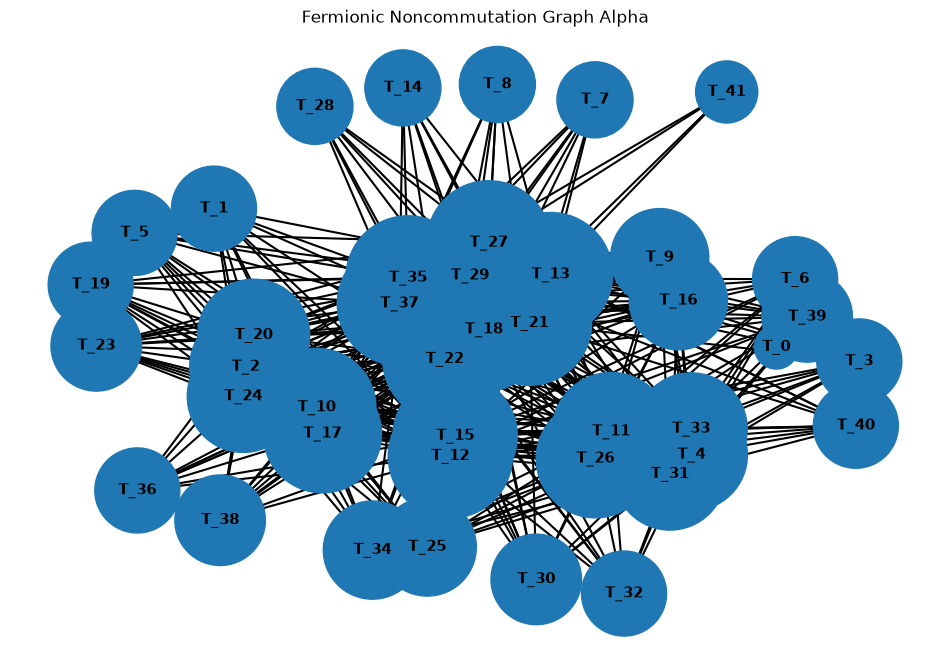

In [27]:
# Cell 2 alpha: Faster H2 / molecular fermionic noncommutation graph
#
# Main idea:
#   1. Use cheap fermionic index rules first.
#   2. Only if rules cannot decide, use exact OpenFermion symbolic commutator.
#   3. Never build sparse/dense matrices.
#
# This cell assumes Cell 1 already defined:
#   hermitian_terms
#   operator_to_string

import time
from collections import Counter

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from openfermion.utils import commutator
from openfermion.transforms import normal_ordered

pd.set_option("display.max_colwidth", None)


# ------------------------------------------------------------
# Fermionic key utilities
# ------------------------------------------------------------

def key_modes(key):
    """
    Modes appearing in one OpenFermion monomial key.

    Example:
        ((3, 1), (0, 1), (3, 0), (0, 0)) -> {0, 3}
    """
    return frozenset(mode for mode, action in key)


def key_creations(key):
    """
    Creation modes in one monomial.
    """
    return frozenset(mode for mode, action in key if action == 1)


def key_annihilations(key):
    """
    Annihilation modes in one monomial.
    """
    return frozenset(mode for mode, action in key if action == 0)


def key_net_delta(key):
    """
    Net occupation change caused by a monomial.

    creation contributes +1
    annihilation contributes -1

    For example:
        a_2^dagger a_1^dagger a_3 a_0
    has delta:
        +1 on modes 2 and 1
        -1 on modes 3 and 0
    """
    delta = Counter()

    for mode, action in key:
        if action == 1:
            delta[mode] += 1
        else:
            delta[mode] -= 1

    return delta


def is_diagonal_key(key):
    """
    True if a monomial preserves occupation mode-by-mode.

    Examples:
        a_p^dagger a_p is diagonal.
        a_p^dagger a_q^dagger a_q a_p is diagonal.
        a_p^dagger a_q is not diagonal when p != q.
    """
    delta = key_net_delta(key)
    return all(value == 0 for value in delta.values())


def is_even_key(key):
    """
    Electronic Hamiltonian terms normally have even fermionic parity:
    length 0, 2, or 4.
    """
    return len(key) % 2 == 0


# ------------------------------------------------------------
# Safe monomial-level commutation rules
# ------------------------------------------------------------

def diagonal_key_commutes_with_key(diagonal_key, other_key):
    """
    Safe rule:

    A diagonal occupation operator depending on modes S commutes with another
    monomial if the other monomial has zero net occupation change on every
    mode in S.
    """
    support = key_modes(diagonal_key)
    delta = key_net_delta(other_key)

    return all(delta.get(mode, 0) == 0 for mode in support)


def no_cross_contractions_even_commute(key_a, key_b):
    """
    Safe rule for normal-ordered even fermionic monomials.

    If there are no possible cross contractions:
        annihilations(A) intersect creations(B) = empty
        annihilations(B) intersect creations(A) = empty

    then even monomials commute.

    This catches many cases beyond completely disjoint support.
    """
    if not is_even_key(key_a) or not is_even_key(key_b):
        return False

    a_ann = key_annihilations(key_a)
    a_cre = key_creations(key_a)

    b_ann = key_annihilations(key_b)
    b_cre = key_creations(key_b)

    return a_ann.isdisjoint(b_cre) and b_ann.isdisjoint(a_cre)


def monomial_pair_definitely_commutes(key_a, key_b):
    """
    Return (True, reason) only when we are sure two monomials commute.
    Return (False, None) if the rule cannot decide.

    Important:
        False here does NOT mean noncommuting.
        It only means "unknown; use exact symbolic fallback."
    """
    # Identity commutes with everything.
    if key_a == () or key_b == ():
        return True, "identity"

    # Any monomial commutes with itself.
    if key_a == key_b:
        return True, "same_monomial"

    # Diagonal occupation-like monomials commute with each other.
    if is_diagonal_key(key_a) and is_diagonal_key(key_b):
        return True, "diagonal_diagonal"

    # Diagonal with excitation-like term, if excitation preserves diagonal support.
    if is_diagonal_key(key_a) and diagonal_key_commutes_with_key(key_a, key_b):
        return True, "diagonal_support_preserved"

    if is_diagonal_key(key_b) and diagonal_key_commutes_with_key(key_b, key_a):
        return True, "diagonal_support_preserved"

    # Even monomials with no cross contractions commute.
    if no_cross_contractions_even_commute(key_a, key_b):
        return True, "no_cross_contractions_even"

    return False, None


# ------------------------------------------------------------
# Operator-level metadata and precheck
# ------------------------------------------------------------

def operator_metadata(op):
    """
    Precompute simple structural data for one FermionOperator.
    """
    keys = list(op.terms.keys())

    modes = set()
    for key in keys:
        modes.update(key_modes(key))

    return {
        "is_zero": len(keys) == 0,
        "only_identity": len(keys) == 1 and keys[0] == (),
        "modes": frozenset(modes),
        "is_even": all(is_even_key(key) for key in keys),
        "is_diagonal": all(is_diagonal_key(key) for key in keys),
        "number_of_monomials": len(keys),
    }


def operator_pair_definitely_commutes(A, B, meta_A, meta_B):
    """
    Return (True, reason) only for guaranteed-commuting pairs.
    Return (False, None) when unresolved.
    """
    if meta_A["is_zero"] or meta_B["is_zero"]:
        return True, "zero"

    if meta_A["only_identity"] or meta_B["only_identity"]:
        return True, "identity"

    # Very cheap global rule:
    # disjoint even fermionic operators commute.
    if (
        meta_A["is_even"]
        and meta_B["is_even"]
        and meta_A["modes"].isdisjoint(meta_B["modes"])
    ):
        return True, "disjoint_even_support"

    # Diagonal occupation-like operators commute with each other.
    if meta_A["is_diagonal"] and meta_B["is_diagonal"]:
        return True, "diagonal_diagonal"

    # More detailed but still cheap:
    # if every monomial pair has a safe commuting reason, the sums commute.
    reasons = Counter()

    for key_a in A.terms:
        for key_b in B.terms:
            ok, reason = monomial_pair_definitely_commutes(key_a, key_b)

            if not ok:
                return False, None

            reasons[reason] += 1

    if len(reasons) > 0:
        main_reason = reasons.most_common(1)[0][0]
        return True, f"all_monomial_pairs_{main_reason}"

    return False, None


# ------------------------------------------------------------
# Exact symbolic fallback
# ------------------------------------------------------------

def exact_symbolic_fermionic_commutator(A, B, tol=1e-12):
    """
    Exact symbolic commutator in fermionic algebra.

    This does not build a 2^n matrix.
    """
    C = normal_ordered(commutator(A, B))
    C.compress(abs_tol=tol)
    return C


# ------------------------------------------------------------
# Alpha graph builder
# ------------------------------------------------------------

def build_fermionic_noncommutation_graph_alpha(
    hermitian_terms,
    tol=1e-12,
    store_commutators=False,
):
    """
    Build noncommutation graph using:
        fast safe index rules first,
        exact symbolic OpenFermion fallback only when needed.

    Parameters
    ----------
    hermitian_terms:
        list of FermionOperator terms T_i from Cell 1.

    tol:
        numerical compression tolerance.

    store_commutators:
        False is recommended for large molecules.
        True is useful for H2 debugging, but can be memory-heavy.

    Returns
    -------
    G:
        networkx.Graph

    stats_df:
        pandas.DataFrame with timing and skip counts
    """
    t_start = time.perf_counter()

    G = nx.Graph()
    stats = Counter()

    metadata = [operator_metadata(T) for T in hermitian_terms]

    # Add vertices.
    for i, T in enumerate(hermitian_terms):
        G.add_node(
            i,
            label=f"T_{i}",
            operator=T,
            operator_string=operator_to_string(T),
            number_of_monomials=len(T.terms),
            modes=sorted(metadata[i]["modes"]),
            is_diagonal=metadata[i]["is_diagonal"],
            is_even=metadata[i]["is_even"],
        )

    n = len(hermitian_terms)

    # Pairwise graph construction.
    for i in range(n):
        A = hermitian_terms[i]
        meta_A = metadata[i]

        for j in range(i + 1, n):
            B = hermitian_terms[j]
            meta_B = metadata[j]

            stats["total_pairs"] += 1

            # 1. Fast guaranteed-commuting rules.
            definitely_commutes, reason = operator_pair_definitely_commutes(
                A, B, meta_A, meta_B
            )

            if definitely_commutes:
                stats["pairs_skipped_by_index_rules"] += 1
                stats[f"skip_{reason}"] += 1
                continue

            # 2. Exact symbolic fallback.
            stats["pairs_sent_to_exact_symbolic"] += 1

            Cij = exact_symbolic_fermionic_commutator(A, B, tol=tol)

            if len(Cij.terms) != 0:
                stats["noncommuting_edges"] += 1

                edge_data = {
                    "method": "exact_symbolic_fallback",
                    "meaning": f"[T_{i}, T_{j}] != 0",
                }

                if store_commutators:
                    edge_data["commutator"] = Cij
                    edge_data["commutator_string"] = operator_to_string(Cij)
                else:
                    edge_data["commutator_string"] = (
                        "(not stored; rerun with store_commutators=True)"
                    )

                G.add_edge(i, j, **edge_data)

            else:
                stats["exact_symbolic_found_commuting"] += 1

    elapsed = time.perf_counter() - t_start

    stats["vertices"] = n
    stats["edges"] = G.number_of_edges()
    stats["commuting_pairs"] = stats["total_pairs"] - G.number_of_edges()
    stats["elapsed_seconds"] = elapsed

    stats_df = pd.DataFrame([dict(stats)])

    return G, stats_df


# ------------------------------------------------------------
# Run alpha graph builder
# ------------------------------------------------------------

# For H2 debugging, you can set store_commutators=True.
# For larger molecules, keep this False.
G_alpha, stats_df = build_fermionic_noncommutation_graph_alpha(
    hermitian_terms,
    tol=1e-12,
    store_commutators=False,
)

print("=== Fermionic noncommutation graph alpha summary ===")
display(stats_df)

print("Number of vertices / fermionic terms:", G_alpha.number_of_nodes())
print("Number of noncommuting pairs / edges:", G_alpha.number_of_edges())
print("Is graph bipartite?", nx.is_bipartite(G_alpha))


# ------------------------------------------------------------
# Vertex table
# ------------------------------------------------------------

vertex_rows = []

for i, data in G_alpha.nodes(data=True):
    vertex_rows.append(
        {
            "vertex": f"T_{i}",
            "degree": G_alpha.degree[i],
            "commutes_with_all": G_alpha.degree[i] == 0,
            "number_of_monomials": data["number_of_monomials"],
            "modes": data["modes"],
            "is_diagonal": data["is_diagonal"],
            "fermionic_term": data["operator_string"],
        }
    )

vertex_df_alpha = pd.DataFrame(vertex_rows)

print("\n=== Alpha vertices: fermionic terms ===")
display(vertex_df_alpha)


# ------------------------------------------------------------
# Edge table
# ------------------------------------------------------------

edge_rows = []

for i, j, data in G_alpha.edges(data=True):
    edge_rows.append(
        {
            "source": f"T_{i}",
            "target": f"T_{j}",
            "meaning": data["meaning"],
            "method": data["method"],
            "commutator": data["commutator_string"],
        }
    )

edge_df_alpha = pd.DataFrame(edge_rows)

print("\n=== Alpha edges: noncommuting pairs ===")
display(edge_df_alpha)


# ------------------------------------------------------------
# Draw graph
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

pos = nx.kamada_kawai_layout(G_alpha)

node_labels = {
    i: f"T_{i}"
    for i in G_alpha.nodes()
}

node_sizes = [
    1000 + 250 * G_alpha.degree[i]
    for i in G_alpha.nodes()
]

nx.draw_networkx_nodes(G_alpha, pos, node_size=node_sizes)
nx.draw_networkx_edges(G_alpha, pos, width=1.5)
nx.draw_networkx_labels(
    G_alpha,
    pos,
    labels=node_labels,
    font_size=11,
    font_weight="bold",
)

plt.title("Fermionic Noncommutation Graph Alpha")
plt.axis("off")
plt.show()

=== Fermionic noncommutation graph summary ===
Number of vertices / fermionic terms: 42
Number of total unordered pairs: 861
Number of noncommuting pairs / edges: 376
Number of commuting pairs: 485
Is graph bipartite? False

=== Vertices: fermionic terms ===


,vertex,degree,commutes_with_all,fermionic_term
0,T_0,0,True,-6.76981321 I
1,T_1,11,False,-0.79527274 a_0^dagger a_0
2,T_2,22,False,+0.04614520 a_0^dagger a_2 + +0.04614520 a_2^dagger a_0
3,T_3,11,False,-0.79527274 a_1^dagger a_1
4,T_4,22,False,+0.04614520 a_1^dagger a_3 + +0.04614520 a_3^dagger a_1
5,T_5,11,False,-0.36549246 a_2^dagger a_2
6,T_6,11,False,-0.36549246 a_3^dagger a_3
7,T_7,8,False,-0.36748235 a_4^dagger a_4
8,T_8,8,False,-0.36748235 a_5^dagger a_5
9,T_9,16,False,-0.49779091 a_1^dagger a_0^dagger a_1 a_0



=== Edges: noncommuting pairs ===


,source,target,meaning,commutator
0,T_1,T_2,"[T_1, T_2] != 0",-0.03669802 a_0^dagger a_2 + +0.03669802 a_2^dagger a_0
1,T_1,T_10,"[T_1, T_10] != 0",+0.03669817 a_1^dagger a_0^dagger a_2 a_1 + -0.03669817 a_2^dagger a_1^dagger a_1 a_0
2,T_1,T_12,"[T_1, T_12] != 0",+0.00933004 a_1^dagger a_0^dagger a_3 a_2 + -0.00933004 a_3^dagger a_2^dagger a_1 a_0
3,T_1,T_13,"[T_1, T_13] != 0",+0.01930894 a_1^dagger a_0^dagger a_5 a_4 + -0.01930894 a_5^dagger a_4^dagger a_1 a_0
4,T_1,T_15,"[T_1, T_15] != 0",+0.00933004 a_2^dagger a_1^dagger a_3 a_0 + -0.00933004 a_3^dagger a_0^dagger a_2 a_1
...,...,...,...,...
371,T_33,T_40,"[T_33, T_40] != 0",+0.00360042 a_5^dagger a_1^dagger a_5 a_3 + -0.00360042 a_5^dagger a_3^dagger a_5 a_1
372,T_34,T_35,"[T_34, T_35] != 0",-0.01402522 a_3^dagger a_2^dagger a_5 a_4 + +0.01402522 a_5^dagger a_4^dagger a_3 a_2
373,T_35,T_41,"[T_35, T_41] != 0",-0.01294024 a_3^dagger a_2^dagger a_5 a_4 + +0.01294024 a_5^dagger a_4^dagger a_3 a_2
374,T_37,T_38,"[T_37, T_38] != 0",+0.01167363 a_4^dagger a_3^dagger a_5 a_2 + -0.01167363 a_5^dagger a_2^dagger a_4 a_3


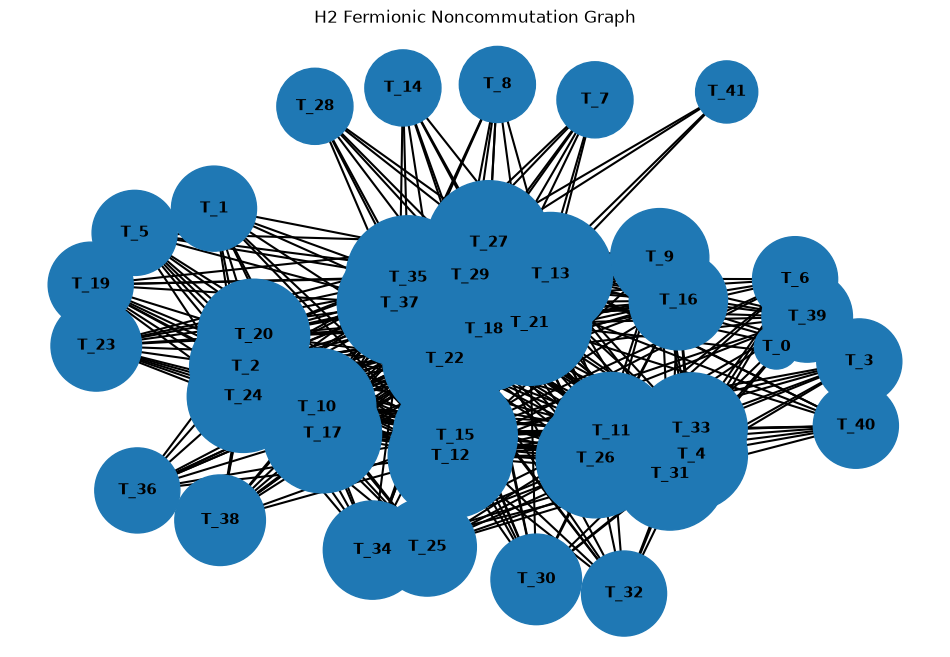

In [28]:
# Cell 2: Build the H2 fermionic noncommutation graph

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from openfermion.transforms import normal_ordered

pd.set_option("display.max_colwidth", None)


def fermionic_commutator(A, B, tol=1e-12):
    """
    Compute [A, B] = AB - BA directly in the fermionic algebra.
    """
    C = normal_ordered(A * B - B * A)
    C.compress(abs_tol=tol)
    return C


def commute(A, B, tol=1e-12):
    """
    Return True if [A, B] = 0.
    """
    C = fermionic_commutator(A, B, tol=tol)
    return len(C.terms) == 0


# ------------------------------------------------------------
# Build noncommutation graph
# ------------------------------------------------------------
# Vertex i = Hermitian fermionic term T_i
# Edge (i, j) exists if [T_i, T_j] != 0

G = nx.Graph()

for i, T in enumerate(hermitian_terms):
    G.add_node(
        i,
        label=f"T_{i}",
        operator=T,
        operator_string=operator_to_string(T),
        number_of_monomials=len(T.terms),
    )

for i in range(len(hermitian_terms)):
    for j in range(i + 1, len(hermitian_terms)):
        Cij = fermionic_commutator(hermitian_terms[i], hermitian_terms[j])

        if len(Cij.terms) != 0:
            G.add_edge(
                i,
                j,
                commutator=Cij,
                commutator_string=operator_to_string(Cij),
            )


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

n_vertices = G.number_of_nodes()
n_total_pairs = n_vertices * (n_vertices - 1) // 2
n_noncommuting_pairs = G.number_of_edges()
n_commuting_pairs = n_total_pairs - n_noncommuting_pairs

print("=== Fermionic noncommutation graph summary ===")
print("Number of vertices / fermionic terms:", n_vertices)
print("Number of total unordered pairs:", n_total_pairs)
print("Number of noncommuting pairs / edges:", n_noncommuting_pairs)
print("Number of commuting pairs:", n_commuting_pairs)
print("Is graph bipartite?", nx.is_bipartite(G))


# ------------------------------------------------------------
# Vertex table
# ------------------------------------------------------------

vertex_rows = []

for i, data in G.nodes(data=True):
    vertex_rows.append(
        {
            "vertex": f"T_{i}",
            "degree": G.degree[i],
            "commutes_with_all": G.degree[i] == 0,
            "fermionic_term": data["operator_string"],
        }
    )

vertex_df = pd.DataFrame(vertex_rows)

print("\n=== Vertices: fermionic terms ===")
display(vertex_df)


# ------------------------------------------------------------
# Edge table
# ------------------------------------------------------------

edge_rows = []

for i, j, data in G.edges(data=True):
    edge_rows.append(
        {
            "source": f"T_{i}",
            "target": f"T_{j}",
            "meaning": f"[T_{i}, T_{j}] != 0",
            "commutator": data["commutator_string"],
        }
    )

edge_df = pd.DataFrame(edge_rows)

print("\n=== Edges: noncommuting pairs ===")
display(edge_df)


# ------------------------------------------------------------
# Draw graph
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

pos = nx.kamada_kawai_layout(G)

node_labels = {
    i: f"T_{i}"
    for i in G.nodes()
}

node_sizes = [
    1000 + 250 * G.degree[i]
    for i in G.nodes()
]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes)
nx.draw_networkx_edges(G, pos, width=1.5)
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=11, font_weight="bold")

plt.title("H2 Fermionic Noncommutation Graph")
plt.axis("off")
plt.show()

In [29]:
print("Same edge set?")
print(set(G.edges()) == set(G_alpha.edges()))

Same edge set?
True


In [30]:
# Cell 3: Color graph, build commuting blocks, map JW/BK, verify commutation

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from itertools import combinations
from openfermion.ops import FermionOperator
from openfermion.transforms import normal_ordered, jordan_wigner, bravyi_kitaev

pd.set_option("display.max_colwidth", None)


# ------------------------------------------------------------
# 1. Color the noncommutation graph
# ------------------------------------------------------------
# Since edges mean noncommutation, each color class is a commuting group.

coloring = nx.coloring.greedy_color(G, strategy="largest_first")

color_groups = {}

for node, color in coloring.items():
    color_groups.setdefault(color, []).append(node)

for color in color_groups:
    color_groups[color] = sorted(color_groups[color])

color_names = [
    "red",
    "blue",
    "green",
    "orange",
    "purple",
    "brown",
    "pink",
    "gray",
]

color_name = {
    color: color_names[color] if color < len(color_names) else f"color_{color}"
    for color in color_groups
}

num_grouped_terms = sum(len(nodes) for nodes in color_groups.values())

print("Number of fermionic terms / vertices:", G.number_of_nodes())
print("Number of colors / commuting groups:", len(color_groups))
print("Number of grouped terms:", num_grouped_terms)

assert num_grouped_terms == G.number_of_nodes()


# ------------------------------------------------------------
# 2. Verify each color group is mutually commuting
# ------------------------------------------------------------

def verify_commuting_group(nodes, tol=1e-12):
    for i, j in combinations(nodes, 2):
        A = G.nodes[i]["operator"]
        B = G.nodes[j]["operator"]

        if not commute(A, B, tol=tol):
            return False

    return True


group_summary_rows = []

for color, nodes in sorted(color_groups.items()):
    group_summary_rows.append(
        {
            "color_id": color,
            "color_name": color_name[color],
            "number_of_terms": len(nodes),
            "vertices": [f"T_{i}" for i in nodes],
            "verified_mutually_commuting": verify_commuting_group(nodes),
        }
    )

group_summary_df = pd.DataFrame(group_summary_rows)

print("\n=== Commuting groups from graph coloring ===")
display(group_summary_df)


# ------------------------------------------------------------
# 3. Build Hamiltonian pieces by color
# ------------------------------------------------------------

H_by_color = {}

for color, nodes in sorted(color_groups.items()):
    H_color = FermionOperator.zero()

    for node in nodes:
        H_color += G.nodes[node]["operator"]

    H_color = normal_ordered(H_color)
    H_color.compress(abs_tol=1e-12)

    H_by_color[color] = H_color


color_block_rows = []

for color, nodes in sorted(color_groups.items()):
    for local_index, node in enumerate(nodes, start=1):
        color_block_rows.append(
            {
                "color_block": f"H_{color_name[color]}",
                "local_term_name": f"{color_name[color][0].upper()}_{local_index}",
                "vertex": f"T_{node}",
                "fermionic_term": G.nodes[node]["operator_string"],
            }
        )

color_block_df = pd.DataFrame(color_block_rows)

print("\n=== Which T_i belongs to which color block ===")
display(color_block_df)


print("\n=== Hamiltonian split by commuting color groups ===")

for color, H_color in H_by_color.items():
    nodes = color_groups[color]

    print("\n" + "=" * 80)
    print(f"H_{color_name[color]} consists of:")
    print(" + ".join([f"T_{node}" for node in nodes]))

    print(f"\nSummed operator H_{color_name[color]} =")
    print(H_color)


# ------------------------------------------------------------
# 4. Trotter ordering induced by color groups
# ------------------------------------------------------------

trotter_order = []

for color, nodes in sorted(color_groups.items()):
    for node in nodes:
        trotter_order.append(node)

print("\n=== Trotter order by commuting color groups ===")
print([f"T_{i}" for i in trotter_order])


# ------------------------------------------------------------
# 5. Helper functions for JW/BK output
# ------------------------------------------------------------

def sort_qubit_key(term):
    return (len(term), term)


def format_qubit_term(term):
    if term == ():
        return "I"

    return " ".join([f"{pauli}{qubit}" for qubit, pauli in term])


def qubit_coeff_to_str(c, digits=8):
    c = complex(c)
    if abs(c.imag) < 1e-12:
        return f"{c.real:+.{digits}f}"
    return f"{c.real:+.{digits}f}{c.imag:+.{digits}f}j"


def qubit_operator_to_string(op, digits=8):
    pieces = []

    for term, coeff in sorted(op.terms.items(), key=lambda item: sort_qubit_key(item[0])):
        pieces.append(f"{qubit_coeff_to_str(coeff, digits)} {format_qubit_term(term)}")

    if len(pieces) == 0:
        return "0"

    return " + ".join(pieces)


def apply_bk(op, n_qubits):
    try:
        return bravyi_kitaev(op, n_qubits=n_qubits)
    except TypeError:
        return bravyi_kitaev(op, n_qubits)


def qubit_commutator(A, B, tol=1e-12):
    C = A * B - B * A
    C.compress(abs_tol=tol)
    return C


def qubit_commute(A, B, tol=1e-12):
    C = qubit_commutator(A, B, tol=tol)
    return len(C.terms) == 0


# Preserve the active-space qubit count from the fermionic Hamiltonian.
n_qubits = infer_n_qubits_from_fermion_operator(Hf)

print("\nNumber of qubits / spin orbitals:", n_qubits)


# ------------------------------------------------------------
# 6. Map each fermionic vertex T_i to JW(T_i) and BK(T_i)
# ------------------------------------------------------------

mapped_rows = []

for node in sorted(G.nodes()):
    T_i = G.nodes[node]["operator"]

    JW_T_i = jordan_wigner(T_i)
    JW_T_i.compress(abs_tol=1e-12)

    BK_T_i = apply_bk(T_i, n_qubits=n_qubits)
    BK_T_i.compress(abs_tol=1e-12)

    G.nodes[node]["JW_operator"] = JW_T_i
    G.nodes[node]["BK_operator"] = BK_T_i
    G.nodes[node]["JW_operator_string"] = qubit_operator_to_string(JW_T_i)
    G.nodes[node]["BK_operator_string"] = qubit_operator_to_string(BK_T_i)

    node_color = coloring[node]
    node_color_name = color_name[node_color]

    mapped_rows.append(
        {
            "color": node_color_name,
            "vertex": f"T_{node}",
            "fermionic_term": G.nodes[node]["operator_string"],
            "number_of_JW_Pauli_strings": len(JW_T_i.terms),
            "JW_transform": qubit_operator_to_string(JW_T_i),
            "number_of_BK_Pauli_strings": len(BK_T_i.terms),
            "BK_transform": qubit_operator_to_string(BK_T_i),
        }
    )

mapped_terms_df = pd.DataFrame(mapped_rows)

print("\n=== Fermionic terms mapped to JW and BK ===")
display(mapped_terms_df)


# ------------------------------------------------------------
# 7. Map each color block H_color to JW and BK
# ------------------------------------------------------------

JW_by_color = {}
BK_by_color = {}

block_rows = []

for color, H_color in sorted(H_by_color.items()):
    JW_color = jordan_wigner(H_color)
    JW_color.compress(abs_tol=1e-12)

    BK_color = apply_bk(H_color, n_qubits=n_qubits)
    BK_color.compress(abs_tol=1e-12)

    JW_by_color[color] = JW_color
    BK_by_color[color] = BK_color

    block_rows.append(
        {
            "color_block": f"H_{color_name[color]}",
            "fermionic_vertices": " + ".join([f"T_{node}" for node in color_groups[color]]),
            "number_of_fermionic_terms": len(color_groups[color]),
            "number_of_JW_Pauli_strings": len(JW_color.terms),
            "JW_block": qubit_operator_to_string(JW_color),
            "number_of_BK_Pauli_strings": len(BK_color.terms),
            "BK_block": qubit_operator_to_string(BK_color),
        }
    )

block_map_df = pd.DataFrame(block_rows)

print("\n=== Color blocks mapped to JW and BK ===")
display(block_map_df)


# ------------------------------------------------------------
# 8. Verify same-color terms commute after JW and BK
# ------------------------------------------------------------

verification_rows = []

for color, nodes in sorted(color_groups.items()):
    for i, j in combinations(nodes, 2):
        Ti = G.nodes[i]["operator"]
        Tj = G.nodes[j]["operator"]

        JW_Ti = G.nodes[i]["JW_operator"]
        JW_Tj = G.nodes[j]["JW_operator"]

        BK_Ti = G.nodes[i]["BK_operator"]
        BK_Tj = G.nodes[j]["BK_operator"]

        verification_rows.append(
            {
                "color_group": color_name[color],
                "pair": f"T_{i}, T_{j}",
                "fermionic_commute": commute(Ti, Tj),
                "JW_commute": qubit_commute(JW_Ti, JW_Tj),
                "BK_commute": qubit_commute(BK_Ti, BK_Tj),
            }
        )

verification_df = pd.DataFrame(verification_rows)

print("\n=== Verify commuting groups after JW/BK mapping ===")
display(verification_df)

Number of fermionic terms / vertices: 42
Number of colors / commuting groups: 7
Number of grouped terms: 42

=== Commuting groups from graph coloring ===


,color_id,color_name,number_of_terms,vertices,verified_mutually_commuting
0,0,red,8,"[T_0, T_7, T_8, T_12, T_14, T_15, T_28, T_41]",True
1,1,blue,7,"[T_5, T_6, T_13, T_19, T_21, T_32, T_34]",True
2,2,green,5,"[T_3, T_18, T_22, T_25, T_40]",True
3,3,orange,5,"[T_1, T_16, T_27, T_29, T_36]",True
4,4,purple,3,"[T_9, T_35, T_37]",True
5,5,brown,7,"[T_2, T_10, T_17, T_20, T_24, T_30, T_39]",True
6,6,pink,7,"[T_4, T_11, T_23, T_26, T_31, T_33, T_38]",True



=== Which T_i belongs to which color block ===


,color_block,local_term_name,vertex,fermionic_term
0,H_red,R_1,T_0,-6.76981321 I
1,H_red,R_2,T_7,-0.36748235 a_4^dagger a_4
2,H_red,R_3,T_8,-0.36748235 a_5^dagger a_5
3,H_red,R_4,T_12,-0.01173188 a_1^dagger a_0^dagger a_3 a_2 + -0.01173188 a_3^dagger a_2^dagger a_1 a_0
4,H_red,R_5,T_14,-0.21652178 a_2^dagger a_0^dagger a_2 a_0
5,H_red,R_6,T_15,+0.01173188 a_2^dagger a_1^dagger a_3 a_0 + +0.01173188 a_3^dagger a_0^dagger a_2 a_1
6,H_red,R_7,T_28,-0.21652178 a_3^dagger a_1^dagger a_3 a_1
7,H_red,R_8,T_41,-0.31294551 a_5^dagger a_4^dagger a_5 a_4
8,H_blue,B_1,T_5,-0.36549246 a_2^dagger a_2
9,H_blue,B_2,T_6,-0.36549246 a_3^dagger a_3



=== Hamiltonian split by commuting color groups ===

H_red consists of:
T_0 + T_7 + T_8 + T_12 + T_14 + T_15 + T_28 + T_41

Summed operator H_red =
-6.769813213374241 [] +
-0.011731876127850396 [1^ 0^ 3 2] +
-0.21652178340242412 [2^ 0^ 2 0] +
0.011731876127850396 [2^ 1^ 3 0] +
0.011731876127850396 [3^ 0^ 2 1] +
-0.21652178340242412 [3^ 1^ 3 1] +
-0.011731876127850396 [3^ 2^ 1 0] +
-0.3674823466660677 [4^ 4] +
-0.3129455111594087 [5^ 4^ 5 4] +
-0.3674823466660677 [5^ 5]

H_blue consists of:
T_5 + T_6 + T_13 + T_19 + T_21 + T_32 + T_34

Summed operator H_blue =
-0.02427964203724351 [1^ 0^ 5 4] +
-0.36549246458223683 [2^ 2] +
-0.3391844228114352 [3^ 2^ 3 2] +
-0.36549246458223683 [3^ 3] +
-0.2533752808448427 [4^ 0^ 4 0] +
0.02427964203724351 [4^ 1^ 5 0] +
0.02427964203724351 [5^ 0^ 4 1] +
-0.2533752808448427 [5^ 1^ 5 1] +
-0.02427964203724351 [5^ 4^ 1 0]

H_green consists of:
T_3 + T_18 + T_22 + T_25 + T_40

Summed operator H_green =
-0.7952727391791676 [1^ 1] +
-0.2282536595302745 [2^ 1

,color,vertex,fermionic_term,number_of_JW_Pauli_strings,JW_transform,number_of_BK_Pauli_strings,BK_transform
0,red,T_0,-6.76981321 I,1,-6.76981321 I,1,-6.76981321 I
1,orange,T_1,-0.79527274 a_0^dagger a_0,2,-0.39763637 I + +0.39763637 Z0,2,-0.39763637 I + +0.39763637 Z0
2,brown,T_2,+0.04614520 a_0^dagger a_2 + +0.04614520 a_2^dagger a_0,2,+0.02307260 X0 Z1 X2 + +0.02307260 Y0 Z1 Y2,2,+0.02307260 X0 Y1 Y2 + -0.02307260 Y0 Y1 X2
3,green,T_3,-0.79527274 a_1^dagger a_1,2,-0.39763637 I + +0.39763637 Z1,2,-0.39763637 I + +0.39763637 Z0 Z1
4,pink,T_4,+0.04614520 a_1^dagger a_3 + +0.04614520 a_3^dagger a_1,2,+0.02307260 X1 Z2 X3 + +0.02307260 Y1 Z2 Y3,2,+0.02307260 X1 Z2 + -0.02307260 Z0 X1 Z3
5,blue,T_5,-0.36549246 a_2^dagger a_2,2,-0.18274623 I + +0.18274623 Z2,2,-0.18274623 I + +0.18274623 Z2
6,blue,T_6,-0.36549246 a_3^dagger a_3,2,-0.18274623 I + +0.18274623 Z3,2,-0.18274623 I + +0.18274623 Z1 Z2 Z3
7,red,T_7,-0.36748235 a_4^dagger a_4,2,-0.18374117 I + +0.18374117 Z4,2,-0.18374117 I + +0.18374117 Z4
8,red,T_8,-0.36748235 a_5^dagger a_5,2,-0.18374117 I + +0.18374117 Z5,2,-0.18374117 I + +0.18374117 Z4 Z5
9,purple,T_9,-0.49779091 a_1^dagger a_0^dagger a_1 a_0,4,+0.12444773 I + -0.12444773 Z0 + -0.12444773 Z1 + +0.12444773 Z0 Z1,4,+0.12444773 I + -0.12444773 Z0 + +0.12444773 Z1 + -0.12444773 Z0 Z1



=== Color blocks mapped to JW and BK ===


,color_block,fermionic_vertices,number_of_fermionic_terms,number_of_JW_Pauli_strings,JW_block,number_of_BK_Pauli_strings,BK_block
0,H_red,T_0 + T_7 + T_8 + T_12 + T_14 + T_15 + T_28 + T_41,8,14,-6.95079829 I + -0.05413045 Z0 + -0.05413045 Z1 + -0.05413045 Z2 + -0.05413045 Z3 + +0.10550480 Z4 + +0.10550480 Z5 + +0.05413045 Z0 Z2 + +0.05413045 Z1 Z3 + +0.07823638 Z4 Z5 + -0.00293297 X0 X1 Y2 Y3 + +0.00293297 X0 Y1 Y2 X3 + +0.00293297 Y0 X1 X2 Y3 + -0.00293297 Y0 Y1 X2 X3,14,-6.95079829 I + -0.05413045 Z0 + -0.05413045 Z2 + +0.10550480 Z4 + +0.07823638 Z5 + -0.05413045 Z0 Z1 + +0.05413045 Z0 Z2 + +0.10550480 Z4 Z5 + +0.00293297 X0 Z1 X2 + +0.00293297 Y0 Z1 Y2 + +0.05413045 Z0 Z2 Z3 + -0.05413045 Z1 Z2 Z3 + +0.00293297 X0 Z1 X2 Z3 + +0.00293297 Y0 Z1 Y2 Z3
1,H_blue,T_5 + T_6 + T_13 + T_19 + T_21 + T_32 + T_34,7,14,-0.15400872 I + -0.06334382 Z0 + -0.06334382 Z1 + +0.09795013 Z2 + +0.09795013 Z3 + -0.06334382 Z4 + -0.06334382 Z5 + +0.06334382 Z0 Z4 + +0.06334382 Z1 Z5 + +0.08479611 Z2 Z3 + -0.00606991 X0 X1 Y4 Y5 + +0.00606991 X0 Y1 Y4 X5 + +0.00606991 Y0 X1 X4 Y5 + -0.00606991 Y0 Y1 X4 X5,14,-0.15400872 I + -0.06334382 Z0 + +0.09795013 Z2 + -0.06334382 Z4 + -0.06334382 Z0 Z1 + +0.06334382 Z0 Z4 + +0.08479611 Z1 Z3 + -0.06334382 Z4 Z5 + +0.00606991 X0 Z1 X4 + +0.00606991 X0 X4 Z5 + +0.00606991 Y0 Z1 Y4 + +0.00606991 Y0 Y4 Z5 + +0.09795013 Z1 Z2 Z3 + +0.06334382 Z0 Z1 Z4 Z5
2,H_green,T_3 + T_18 + T_22 + T_25 + T_40,5,11,-0.28033196 I + +0.34057295 Z1 + -0.05706341 Z2 + -0.06024099 Z3 + -0.06024099 Z5 + +0.05706341 Z1 Z2 + +0.06024099 Z3 Z5 + -0.00479792 X0 Z1 Z2 X3 Y4 Y5 + +0.00479792 X0 Z1 Z2 Y3 Y4 X5 + +0.00479792 Y0 Z1 Z2 X3 X4 Y5 + -0.00479792 Y0 Z1 Z2 Y3 X4 X5,11,-0.28033196 I + -0.05706341 Z2 + +0.34057295 Z0 Z1 + -0.06024099 Z4 Z5 + +0.05706341 Z0 Z1 Z2 + -0.06024099 Z1 Z2 Z3 + +0.00479792 X0 X1 Z3 X4 + +0.00479792 Y0 X1 Z3 Y4 + +0.00479792 X0 Y1 Z2 Y4 Z5 + -0.00479792 Y0 Y1 Z2 X4 Z5 + +0.06024099 Z1 Z2 Z3 Z4 Z5
3,H_orange,T_1 + T_16 + T_27 + T_29 + T_36,5,11,-0.28033196 I + +0.34057295 Z0 + -0.06024099 Z2 + -0.05706341 Z3 + -0.06024099 Z4 + +0.05706341 Z0 Z3 + +0.06024099 Z2 Z4 + -0.00479792 X1 X2 X4 X5 + -0.00479792 X1 Y2 Y4 X5 + -0.00479792 Y1 X2 X4 Y5 + -0.00479792 Y1 Y2 Y4 Y5,11,-0.28033196 I + +0.34057295 Z0 + -0.06024099 Z2 + -0.06024099 Z4 + +0.06024099 Z2 Z4 + -0.00479792 X1 X2 X4 + -0.00479792 X1 Y2 Y4 + -0.05706341 Z1 Z2 Z3 + +0.05706341 Z0 Z1 Z2 Z3 + -0.00479792 Z0 Y1 X2 Y4 Z5 + +0.00479792 Z0 Y1 Y2 X4 Z5
4,H_purple,T_9 + T_35 + T_37,3,8,+0.12444773 I + -0.12444773 Z0 + -0.12444773 Z1 + +0.12444773 Z0 Z1 + -0.01033746 X2 X3 Y4 Y5 + +0.01033746 X2 Y3 Y4 X5 + +0.01033746 Y2 X3 X4 Y5 + -0.01033746 Y2 Y3 X4 X5,8,+0.12444773 I + -0.12444773 Z0 + +0.12444773 Z1 + -0.12444773 Z0 Z1 + +0.01033746 X2 X4 Z5 + +0.01033746 Y2 Y4 Z5 + +0.01033746 Z1 X2 Z3 X4 + +0.01033746 Z1 Y2 Z3 Y4
5,H_brown,T_2 + T_10 + T_17 + T_20 + T_24 + T_30 + T_39,7,16,+0.13999218 I + -0.06941373 Z1 + -0.07057845 Z3 + -0.13999218 Z4 + +0.01153635 X0 X2 + +0.01153635 Y0 Y2 + +0.06941373 Z1 Z4 + +0.07057845 Z3 Z4 + +0.01023766 X0 Z1 X2 + +0.01023766 Y0 Z1 Y2 + -0.00137435 X0 Z1 X2 Z3 + +0.00373543 X0 Z1 X2 Z4 + -0.00106249 X0 Z1 X2 Z5 + -0.00137435 Y0 Z1 Y2 Z3 + +0.00373543 Y0 Z1 Y2 Z4 + -0.00106249 Y0 Z1 Y2 Z5,16,+0.13999218 I + -0.13999218 Z4 + -0.06941373 Z0 Z1 + +0.01153635 X0 X1 X2 + +0.01023766 X0 Y1 Y2 + +0.01153635 Y0 X1 Y2 + -0.01023766 Y0 Y1 X2 + +0.06941373 Z0 Z1 Z4 + -0.07057845 Z1 Z2 Z3 + +0.00137435 X0 X1 X2 Z3 + +0.00373543 X0 Y1 Y2 Z4 + +0.00137435 Y0 X1 Y2 Z3 + -0.00373543 Y0 Y1 X2 Z4 + +0.07057845 Z1 Z2 Z3 Z4 + -0.00106249 X0 Y1 Y2 Z4 Z5 + +0.00106249 Y0 Y1 X2 Z4 Z5
6,H_pink,T_4 + T_11 + T_23 + T_26 + T_31 + T_33 + T_38,7,16,+0.13999218 I + -0.06941373 Z0 + -0.07057845 Z2 + -0.13999218 Z5 + +0.06941373 Z0 Z5 + -0.00137435 X1 X3 + -0.00137435 Y1 Y3 + +0.07057845 Z2 Z5 + +0.01023766 X1 Z2 X3 + +0.01023766 Y1 Z2 Y3 + +0.01153635 Z0 X1 Z2 X3 + +0.01153635 Z0 Y1 Z2 Y3 + -0.00106249 X1 Z2 X3 Z4 + +0.00373543 X1 Z2 X3 Z5 + -0.00106249 Y1 Z2 Y3


=== Verify commuting groups after JW/BK mapping ===


,color_group,pair,fermionic_commute,JW_commute,BK_commute
0,red,"T_0, T_7",True,True,True
1,red,"T_0, T_8",True,True,True
2,red,"T_0, T_12",True,True,True
3,red,"T_0, T_14",True,True,True
4,red,"T_0, T_15",True,True,True
...,...,...,...,...,...
109,pink,"T_26, T_33",True,True,True
110,pink,"T_26, T_38",True,True,True
111,pink,"T_31, T_33",True,True,True
112,pink,"T_31, T_38",True,True,True


In [31]:
# Find duplicated JW Pauli strings across fermionic terms T_i

from collections import defaultdict
import pandas as pd

pauli_usage = defaultdict(list)

for node in sorted(G.nodes()):
    JW_T = G.nodes[node]["JW_operator"]

    for pauli_key, coeff in JW_T.terms.items():
        pauli_string = format_qubit_term(pauli_key)

        pauli_usage[pauli_string].append(
            {
                "vertex": f"T_{node}",
                "coefficient": coeff,
                "fermionic_term": G.nodes[node]["operator_string"],
            }
        )

duplicate_rows = []

for pauli_string, appearances in pauli_usage.items():
    if len(appearances) > 1:
        duplicate_rows.append(
            {
                "JW_Pauli_string": pauli_string,
                "number_of_appearances": len(appearances),
                "appears_in_vertices": [x["vertex"] for x in appearances],
                "coefficients": [x["coefficient"] for x in appearances],
            }
        )

duplicate_jw_df = pd.DataFrame(duplicate_rows)
duplicate_jw_df = duplicate_jw_df.sort_values(
    "number_of_appearances",
    ascending=False
).reset_index(drop=True)

print("Total JW Pauli-string appearances:", sum(len(G.nodes[node]["JW_operator"].terms) for node in G.nodes()))
print("Number of unique JW Pauli strings:", len(pauli_usage))
print("Number of duplicated JW Pauli strings:", len(duplicate_jw_df))

display(duplicate_jw_df)

Total JW Pauli-string appearances: 189
Number of unique JW Pauli strings: 82
Number of duplicated JW Pauli strings: 51


,JW_Pauli_string,number_of_appearances,appears_in_vertices,coefficients
0,I,22,"[T_0, T_1, T_3, T_5, T_6, T_7, T_8, T_9, T_14, T_16, T_19, T_23, T_25, T_28, T_30, T_32, T_34, T_36, T_38, T_39, T_40, T_41]","[-6.769813213374241, -0.3976363695895838, -0.3976363695895838, -0.18274623229111842, -0.18274623229111842, -0.18374117333303386, -0.18374117333303386, 0.12444772654769563, 0.05413044585060603, 0.05706341488256862, 0.06334382021121067, 0.06941373072052155, 0.05706341488256862, 0.05413044585060603, 0.06941373072052155, 0.06334382021121067, 0.0847961057028588, 0.06024099269328752, 0.07057844979524039, 0.07057844979524039, 0.06024099269328752, 0.07823637778985218]"
1,Z2,6,"[T_5, T_14, T_25, T_34, T_36, T_38]","[0.18274623229111842, -0.05413044585060603, -0.05706341488256862, -0.0847961057028588, -0.06024099269328752, -0.07057844979524039]"
2,Z0,6,"[T_1, T_9, T_14, T_16, T_19, T_23]","[0.3976363695895838, -0.12444772654769563, -0.05413044585060603, -0.05706341488256862, -0.06334382021121067, -0.06941373072052155]"
3,Z5,6,"[T_8, T_23, T_32, T_38, T_40, T_41]","[0.18374117333303386, -0.06941373072052155, -0.06334382021121067, -0.07057844979524039, -0.06024099269328752, -0.07823637778985218]"
4,Z3,6,"[T_6, T_16, T_28, T_34, T_39, T_40]","[0.18274623229111842, -0.05706341488256862, -0.05413044585060603, -0.0847961057028588, -0.07057844979524039, -0.06024099269328752]"
5,Z4,6,"[T_7, T_19, T_30, T_36, T_39, T_41]","[0.18374117333303386, -0.06334382021121067, -0.06941373072052155, -0.06024099269328752, -0.07057844979524039, -0.07823637778985218]"
6,Z1,6,"[T_3, T_9, T_25, T_28, T_30, T_32]","[0.3976363695895838, -0.12444772654769563, -0.05706341488256862, -0.05413044585060603, -0.06941373072052155, -0.06334382021121067]"
7,X1 Z2 X3,5,"[T_4, T_11, T_26, T_31, T_33]","[0.023072598893409665, -0.011536345885334788, 0.0013743543763790876, 0.0010624877003961833, -0.0037354318515812786]"
8,Y1 Z2 Y3,5,"[T_4, T_11, T_26, T_31, T_33]","[0.023072598893409665, -0.011536345885334788, 0.0013743543763790876, 0.0010624877003961833, -0.0037354318515812786]"
9,X0 Z1 X2,5,"[T_2, T_10, T_17, T_20, T_24]","[0.023072598893409665, -0.011536345885334788, 0.0013743543763790876, -0.0037354318515812786, 0.0010624877003961833]"


In [32]:
# Compute Pauli-duplication ratio for JW and BK

from collections import defaultdict
import pandas as pd

from openfermion.ops import FermionOperator
from openfermion.transforms import jordan_wigner, bravyi_kitaev, normal_ordered


def pauli_support(qubit_op, tol=1e-12, include_identity=True):
    """
    Return the set of Pauli strings with nonzero coefficients.
    """
    qubit_op.compress(abs_tol=tol)

    support = set()

    for pauli_key, coeff in qubit_op.terms.items():
        if abs(coeff) <= tol:
            continue

        if not include_identity and pauli_key == ():
            continue

        support.add(pauli_key)

    return support


def map_fermion_to_qubit(op, mapping="JW", n_qubits=None):
    """
    Map a FermionOperator to a QubitOperator using JW or BK.
    """
    mapping = mapping.upper()

    if mapping == "JW":
        qop = jordan_wigner(op)

    elif mapping == "BK":
        if n_qubits is None:
            raise ValueError("n_qubits is required for BK.")

        try:
            qop = bravyi_kitaev(op, n_qubits=n_qubits)
        except TypeError:
            qop = bravyi_kitaev(op, n_qubits)

    else:
        raise ValueError("mapping must be 'JW' or 'BK'.")

    qop.compress(abs_tol=1e-12)
    return qop


def pauli_duplication_ratio(
    fermionic_terms,
    mapping="JW",
    n_qubits=None,
    include_identity=True,
    tol=1e-12,
):
    """
    Compute

        sum_alpha #mapping(H_alpha) / #mapping(H)

    where H = sum_alpha H_alpha.

    Also returns a duplicate-use table.
    """

    H_full = FermionOperator.zero()

    numerator = 0
    union_support = set()
    pauli_usage = defaultdict(list)

    for alpha, H_alpha in enumerate(fermionic_terms):
        H_full += H_alpha

        Q_alpha = map_fermion_to_qubit(
            H_alpha,
            mapping=mapping,
            n_qubits=n_qubits,
        )

        support_alpha = pauli_support(
            Q_alpha,
            tol=tol,
            include_identity=include_identity,
        )

        numerator += len(support_alpha)
        union_support |= support_alpha

        for pauli_key, coeff in Q_alpha.terms.items():
            if abs(coeff) <= tol:
                continue

            if not include_identity and pauli_key == ():
                continue

            pauli_usage[pauli_key].append(
                {
                    "vertex": f"T_{alpha}",
                    "coefficient": coeff,
                }
            )

    H_full = normal_ordered(H_full)
    H_full.compress(abs_tol=tol)

    Q_full = map_fermion_to_qubit(
        H_full,
        mapping=mapping,
        n_qubits=n_qubits,
    )

    full_support = pauli_support(
        Q_full,
        tol=tol,
        include_identity=include_identity,
    )

    denominator = len(full_support)

    duplication_ratio = numerator / denominator
    union_ratio = numerator / len(union_support)

    summary_df = pd.DataFrame(
        [
            {
                "mapping": mapping.upper(),
                "include_identity": include_identity,
                "sum_alpha_number_of_Pauli_strings": numerator,
                "number_of_unique_Pauli_strings_before_cancellation": len(union_support),
                "number_of_Pauli_strings_in_full_H": denominator,
                "duplication_ratio": duplication_ratio,
                "raw_reuse_ratio_before_cancellation": union_ratio,
            }
        ]
    )

    duplicate_rows = []

    for pauli_key, appearances in pauli_usage.items():
        if len(appearances) <= 1:
            continue

        combined_coeff = Q_full.terms.get(pauli_key, 0.0)

        duplicate_rows.append(
            {
                "Pauli_string": format_qubit_term(pauli_key),
                "number_of_appearances": len(appearances),
                "appears_in_vertices": [x["vertex"] for x in appearances],
                "individual_coefficients": [complex(x["coefficient"]) for x in appearances],
                "combined_coefficient_in_full_H": complex(combined_coeff),
                "survives_in_full_H": abs(combined_coeff) > tol,
            }
        )

    duplicate_df = pd.DataFrame(duplicate_rows)

    if len(duplicate_df) > 0:
        duplicate_df = duplicate_df.sort_values(
            "number_of_appearances",
            ascending=False,
        ).reset_index(drop=True)

    return summary_df, duplicate_df


# ------------------------------------------------------------
# Run for JW
# ------------------------------------------------------------

n_qubits = molecule.n_qubits

jw_summary_df, jw_duplicate_df = pauli_duplication_ratio(
    hermitian_terms,
    mapping="JW",
    n_qubits=n_qubits,
    include_identity=True,
)

print("=== JW Pauli-duplication ratio ===")
display(jw_summary_df)

print("\n=== Duplicated JW Pauli strings ===")
display(jw_duplicate_df)


# ------------------------------------------------------------
# Optional: run for BK too
# ------------------------------------------------------------

bk_summary_df, bk_duplicate_df = pauli_duplication_ratio(
    hermitian_terms,
    mapping="BK",
    n_qubits=n_qubits,
    include_identity=True,
)

print("=== BK Pauli-duplication ratio ===")
display(bk_summary_df)

print("\n=== Duplicated BK Pauli strings ===")
display(bk_duplicate_df)

=== JW Pauli-duplication ratio ===


,mapping,include_identity,sum_alpha_number_of_Pauli_strings,number_of_unique_Pauli_strings_before_cancellation,number_of_Pauli_strings_in_full_H,duplication_ratio,raw_reuse_ratio_before_cancellation
0,JW,True,189,82,62,3.048387,2.304878



=== Duplicated JW Pauli strings ===


,Pauli_string,number_of_appearances,appears_in_vertices,individual_coefficients,combined_coefficient_in_full_H,survives_in_full_H
0,I,22,"[T_0, T_1, T_3, T_5, T_6, T_7, T_8, T_9, T_14, T_16, T_19, T_23, T_25, T_28, T_30, T_32, T_34, T_36, T_38, T_39, T_40, T_41]","[(-6.769813213374241+0j), (-0.3976363695895838+0j), (-0.3976363695895838+0j), (-0.18274623229111842+0j), (-0.18274623229111842+0j), (-0.18374117333303386+0j), (-0.18374117333303386+0j), (0.12444772654769563+0j), (0.05413044585060603+0j), (0.05706341488256862+0j), (0.06334382021121067+0j), (0.06941373072052155+0j), (0.05706341488256862+0j), (0.05413044585060603+0j), (0.06941373072052155+0j), (0.06334382021121067+0j), (0.0847961057028588+0j), (0.06024099269328752+0j), (0.07057844979524039+0j), (0.07057844979524039+0j), (0.06024099269328752+0j), (0.07823637778985218+0j)]",-7.261039+0.000000j,True
1,Z2,6,"[T_5, T_14, T_25, T_34, T_36, T_38]","[(0.18274623229111842+0j), (-0.05413044585060603+0j), (-0.05706341488256862+0j), (-0.0847961057028588+0j), (-0.06024099269328752+0j), (-0.07057844979524039+0j)]",-0.144063+0.000000j,True
2,Z0,6,"[T_1, T_9, T_14, T_16, T_19, T_23]","[(0.3976363695895838+0j), (-0.12444772654769563+0j), (-0.05413044585060603+0j), (-0.05706341488256862+0j), (-0.06334382021121067+0j), (-0.06941373072052155+0j)]",0.029237+0.000000j,True
3,Z5,6,"[T_8, T_23, T_32, T_38, T_40, T_41]","[(0.18374117333303386+0j), (-0.06941373072052155+0j), (-0.06334382021121067+0j), (-0.07057844979524039+0j), (-0.06024099269328752+0j), (-0.07823637778985218+0j)]",-0.158072+0.000000j,True
4,Z3,6,"[T_6, T_16, T_28, T_34, T_39, T_40]","[(0.18274623229111842+0j), (-0.05706341488256862+0j), (-0.05413044585060603+0j), (-0.0847961057028588+0j), (-0.07057844979524039+0j), (-0.06024099269328752+0j)]",-0.144063+0.000000j,True
5,Z4,6,"[T_7, T_19, T_30, T_36, T_39, T_41]","[(0.18374117333303386+0j), (-0.06334382021121067+0j), (-0.06941373072052155+0j), (-0.06024099269328752+0j), (-0.07057844979524039+0j), (-0.07823637778985218+0j)]",-0.158072+0.000000j,True
6,Z1,6,"[T_3, T_9, T_25, T_28, T_30, T_32]","[(0.3976363695895838+0j), (-0.12444772654769563+0j), (-0.05706341488256862+0j), (-0.05413044585060603+0j), (-0.06941373072052155+0j), (-0.06334382021121067+0j)]",0.029237+0.000000j,True
7,X1 Z2 X3,5,"[T_4, T_11, T_26, T_31, T_33]","[(0.023072598893409665+0j), (-0.011536345885334788+0j), (0.0013743543763790876+0j), (0.0010624877003961833+0j), (-0.0037354318515812786+0j)]",0.010238+0.000000j,True
8,Y1 Z2 Y3,5,"[T_4, T_11, T_26, T_31, T_33]","[(0.023072598893409665+0j), (-0.011536345885334788+0j), (0.0013743543763790876+0j), (0.0010624877003961833+0j), (-0.0037354318515812786+0j)]",0.010238+0.000000j,True
9,X0 Z1 X2,5,"[T_2, T_10, T_17, T_20, T_24]","[(0.023072598893409665+0j), (-0.011536345885334788+0j), (0.0013743543763790876+0j), (-0.0037354318515812786+0j), (0.0010624877003961833+0j)]",0.010238+0.000000j,True


=== BK Pauli-duplication ratio ===


,mapping,include_identity,sum_alpha_number_of_Pauli_strings,number_of_unique_Pauli_strings_before_cancellation,number_of_Pauli_strings_in_full_H,duplication_ratio,raw_reuse_ratio_before_cancellation
0,BK,True,189,82,62,3.048387,2.304878



=== Duplicated BK Pauli strings ===


,Pauli_string,number_of_appearances,appears_in_vertices,individual_coefficients,combined_coefficient_in_full_H,survives_in_full_H
0,I,22,"[T_0, T_1, T_3, T_5, T_6, T_7, T_8, T_9, T_14, T_16, T_19, T_23, T_25, T_28, T_30, T_32, T_34, T_36, T_38, T_39, T_40, T_41]","[(-6.769813213374241+0j), (-0.3976363695895838+0j), (-0.3976363695895838+0j), (-0.18274623229111842+0j), (-0.18274623229111842+0j), (-0.18374117333303386+0j), (-0.18374117333303386+0j), (0.12444772654769563+0j), (0.05413044585060603+0j), (0.05706341488256862+0j), (0.06334382021121067+0j), (0.06941373072052155+0j), (0.05706341488256862+0j), (0.05413044585060603+0j), (0.06941373072052155+0j), (0.06334382021121067+0j), (0.0847961057028588+0j), (0.06024099269328752+0j), (0.07057844979524039+0j), (0.07057844979524039+0j), (0.06024099269328752+0j), (0.07823637778985218+0j)]",-7.261039+0.000000j,True
1,Z2,6,"[T_5, T_14, T_25, T_34, T_36, T_38]","[(0.18274623229111842+0j), (-0.05413044585060603+0j), (-0.05706341488256862+0j), (-0.0847961057028588+0j), (-0.06024099269328752+0j), (-0.07057844979524039+0j)]",-0.144063+0.000000j,True
2,Z0,6,"[T_1, T_9, T_14, T_16, T_19, T_23]","[(0.3976363695895838+0j), (-0.12444772654769563+0j), (-0.05413044585060603+0j), (-0.05706341488256862+0j), (-0.06334382021121067+0j), (-0.06941373072052155+0j)]",0.029237+0.000000j,True
3,Z4 Z5,6,"[T_8, T_23, T_32, T_38, T_40, T_41]","[(0.18374117333303386+0j), (-0.06941373072052155+0j), (-0.06334382021121067+0j), (-0.07057844979524039+0j), (-0.06024099269328752+0j), (-0.07823637778985218+0j)]",-0.158072+0.000000j,True
4,Z1 Z2 Z3,6,"[T_6, T_16, T_28, T_34, T_39, T_40]","[(0.18274623229111842+0j), (-0.05706341488256862+0j), (-0.05413044585060603+0j), (-0.0847961057028588+0j), (-0.07057844979524039+0j), (-0.06024099269328752+0j)]",-0.144063+0.000000j,True
5,Z4,6,"[T_7, T_19, T_30, T_36, T_39, T_41]","[(0.18374117333303386+0j), (-0.06334382021121067+0j), (-0.06941373072052155+0j), (-0.06024099269328752+0j), (-0.07057844979524039+0j), (-0.07823637778985218+0j)]",-0.158072+0.000000j,True
6,Z0 Z1,6,"[T_3, T_9, T_25, T_28, T_30, T_32]","[(0.3976363695895838+0j), (-0.12444772654769563+0j), (-0.05706341488256862+0j), (-0.05413044585060603+0j), (-0.06941373072052155+0j), (-0.06334382021121067+0j)]",0.029237+0.000000j,True
7,X1 Z2,5,"[T_4, T_11, T_26, T_31, T_33]","[(0.023072598893409665+0j), (-0.011536345885334788+0j), (0.0013743543763790876+0j), (0.0010624877003961833+0j), (-0.0037354318515812786+0j)]",0.010238+0.000000j,True
8,Z0 X1 Z3,5,"[T_4, T_11, T_26, T_31, T_33]","[(-0.023072598893409665+0j), (0.011536345885334788+0j), (-0.0013743543763790876+0j), (-0.0010624877003961833+0j), (0.0037354318515812786+0j)]",-0.010238+0.000000j,True
9,Y0 Y1 X2,5,"[T_2, T_10, T_17, T_20, T_24]","[(-0.023072598893409665+0j), (0.011536345885334788+0j), (-0.0013743543763790876+0j), (0.0037354318515812786+0j), (-0.0010624877003961833+0j)]",-0.010238+0.000000j,True


In [33]:
# New Cell 1: Settings and matrix-free state-evolution functions

import gc
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse.linalg import LinearOperator, expm_multiply

from openfermion.ops import FermionOperator, QubitOperator
from openfermion.transforms import jordan_wigner, bravyi_kitaev


# ============================================================
# User settings
# ============================================================

# Fast screening:
#     True  -> only t = 1.0
#     False -> five time values from 0 to 1
FAST_MODE = True

if FAST_MODE:
    T_VALUES = np.array([1.0])
else:
    T_VALUES = np.linspace(0.0, 1.0, 5)

# Retain both mappings for the final comparison.
# Change to ("JW",) to approximately halve the work during testing.
RUN_MAPPINGS = ("JW",) #, "BK")

# First-order Trotter formula with one Trotter step.
N_TROTTER_STEPS = 1

ATOL = 1.0e-12

# LiH has four total electrons.
# Freezing one occupied spatial orbital removes two electrons,
# leaving two active electrons.
REFERENCE_ELECTRONS = (
    int(molecule.n_electrons - 2 * len(OCCUPIED_INDICES))
    if USE_ACTIVE_SPACE
    else int(molecule.n_electrons)
)


# ============================================================
# Clean and compile OpenFermion QubitOperators
# ============================================================

def clean_qubit_operator(qop, atol=ATOL):
    """
    Remove numerically negligible Pauli coefficients.
    """
    cleaned = QubitOperator()

    for pauli_term, coefficient in qop.terms.items():
        if abs(coefficient) > atol:
            cleaned += QubitOperator(pauli_term, coefficient)

    cleaned.compress(abs_tol=atol)
    return cleaned


def compile_qubit_operator(qop, n_qubits, atol=ATOL):
    """
    Convert a QubitOperator into a lightweight matrix-free representation.

    No 2^n by 2^n matrix is constructed.
    """
    qop = clean_qubit_operator(qop, atol=atol)

    compiled_terms = []
    identity_coefficient = 0.0 + 0.0j

    for pauli_term, coefficient in qop.terms.items():
        actions = []

        for qubit, pauli in pauli_term:
            if qubit >= n_qubits:
                raise ValueError(
                    f"Pauli term uses qubit {qubit}, "
                    f"but n_qubits={n_qubits}."
                )

            # OpenFermion computational-basis convention:
            # qubit 0 is the leftmost / most significant bit.
            shift = n_qubits - 1 - qubit
            mask = np.uint64(1) << np.uint64(shift)

            actions.append((mask, pauli))

        if pauli_term == ():
            identity_coefficient = complex(coefficient)

        compiled_terms.append(
            {
                "actions": tuple(actions),
                "coefficient": complex(coefficient),
            }
        )

    return {
        "terms": compiled_terms,
        "identity_coefficient": identity_coefficient,
    }


# ============================================================
# Matrix-free Pauli action
# ============================================================

def apply_compiled_pauli_to_state(psi, actions, basis_indices):
    """
    Apply one Pauli string to a state vector without constructing its matrix.
    """
    if len(actions) == 0:
        return psi.copy()

    target_indices = basis_indices.copy()
    phase = np.ones(psi.shape[0], dtype=np.complex128)

    for mask, pauli in actions:
        bit_is_one = (basis_indices & mask) != 0

        if pauli == "X":
            target_indices ^= mask

        elif pauli == "Y":
            target_indices ^= mask
            phase *= np.where(bit_is_one, -1j, 1j)

        elif pauli == "Z":
            phase *= np.where(bit_is_one, -1.0, 1.0)

        else:
            raise ValueError(f"Unknown Pauli operator: {pauli}")

    result = np.empty_like(psi, dtype=np.complex128)
    result[target_indices] = phase * psi

    return result


def scaled_linear_operator(compiled_qop, n_qubits, scale):
    """
    Return a LinearOperator representing:

        scale * H

    where H is the compiled QubitOperator.
    """
    dimension = 2 ** n_qubits
    basis_indices = np.arange(dimension, dtype=np.uint64)

    def matvec(vector):
        vector = np.asarray(vector, dtype=np.complex128).reshape(-1)
        result = np.zeros(dimension, dtype=np.complex128)

        for term in compiled_qop["terms"]:
            coefficient = scale * term["coefficient"]

            result += coefficient * apply_compiled_pauli_to_state(
                vector,
                term["actions"],
                basis_indices,
            )

        return result

    def rmatvec(vector):
        vector = np.asarray(vector, dtype=np.complex128).reshape(-1)
        result = np.zeros(dimension, dtype=np.complex128)

        for term in compiled_qop["terms"]:
            coefficient = np.conjugate(
                scale * term["coefficient"]
            )

            result += coefficient * apply_compiled_pauli_to_state(
                vector,
                term["actions"],
                basis_indices,
            )

        return result

    linear_operator = LinearOperator(
        shape=(dimension, dimension),
        matvec=matvec,
        rmatvec=rmatvec,
        dtype=np.complex128,
    )

    trace_scaled = (
        scale
        * compiled_qop["identity_coefficient"]
        * dimension
    )

    return linear_operator, trace_scaled


# ============================================================
# Exact and Trotter state evolution
# ============================================================

def evolve_compiled_operator(compiled_qop, psi, t, n_qubits):
    """
    Calculate exp(-i t H)|psi> without constructing exp(-i t H).
    """
    if abs(t) < ATOL:
        return psi.copy()

    generator, trace_generator = scaled_linear_operator(
        compiled_qop=compiled_qop,
        n_qubits=n_qubits,
        scale=-1j * t,
    )

    return expm_multiply(
        generator,
        psi,
        traceA=trace_generator,
    )


def first_order_trotter_state(
    compiled_term_operators,
    psi0,
    t,
    n_qubits,
    n_steps=1,
):
    """
    First-order Trotter evolution applied directly to a state.

    The first listed term acts first, matching the original fermionic
    notebook convention:

        U <- exp(-i dt H_k) @ U
    """
    psi = np.asarray(psi0, dtype=np.complex128).copy()

    if abs(t) < ATOL:
        return psi

    dt = t / n_steps

    for _ in range(n_steps):
        for compiled_term in compiled_term_operators:
            psi = evolve_compiled_operator(
                compiled_qop=compiled_term,
                psi=psi,
                t=dt,
                n_qubits=n_qubits,
            )

    return psi


def calculate_state_metrics(psi_trotter, psi_exact):
    """
    Calculate state-vector error and phase-insensitive infidelity.
    """
    exact_norm = np.linalg.norm(psi_exact)
    trotter_norm = np.linalg.norm(psi_trotter)

    if exact_norm == 0 or trotter_norm == 0:
        raise ValueError("Encountered a zero-norm state.")

    psi_exact_normalized = psi_exact / exact_norm
    psi_trotter_normalized = psi_trotter / trotter_norm

    state_based_error = np.linalg.norm(
        psi_trotter_normalized - psi_exact_normalized
    )

    overlap = np.vdot(
        psi_exact_normalized,
        psi_trotter_normalized,
    )

    state_infidelity = 1.0 - abs(overlap) ** 2
    state_infidelity = float(np.clip(state_infidelity, 0.0, 1.0))

    return {
        "state_based_error": float(state_based_error),
        "state_infidelity": state_infidelity,
        "state_overlap_abs": float(abs(overlap)),
    }


print("State-based matrix-free functions are ready.")
print("FAST_MODE:", FAST_MODE)
print("T_VALUES:", T_VALUES)
print("RUN_MAPPINGS:", RUN_MAPPINGS)

State-based matrix-free functions are ready.
FAST_MODE: True
T_VALUES: [1.]
RUN_MAPPINGS: ('JW',)


In [34]:
# Revised New Cell 2:
# Build the four primary JW experiment definitions

from openfermion.ops import QubitOperator
from openfermion.transforms import jordan_wigner


# ============================================================
# Basic Hamiltonian information
# ============================================================

if "Hf" not in globals():
    if "H_f" in globals():
        Hf = H_f
    else:
        raise NameError(
            "The fermionic Hamiltonian must be named Hf or H_f."
        )

n_qubits = infer_n_qubits_from_fermion_operator(Hf)

if REFERENCE_ELECTRONS is None:
    n_reference_electrons = int(molecule.n_electrons)
else:
    n_reference_electrons = int(REFERENCE_ELECTRONS)

if "MOLECULE_NAME" in globals():
    MOLECULE_LABEL = str(MOLECULE_NAME)
elif hasattr(molecule, "name") and molecule.name:
    MOLECULE_LABEL = str(molecule.name)
else:
    MOLECULE_LABEL = "H2"


# ============================================================
# Fermionic orderings
# ============================================================

def graph_fermionic_operator(node):
    """
    Recover the FermionOperator associated with one graph node.
    """
    if "operator" in G.nodes[node]:
        return G.nodes[node]["operator"]

    return hermitian_terms[node]


# Baseline: original Hermitian-term order from Cell 1
raw_fermionic_order = list(hermitian_terms)


# Graph-color-induced order from Cell 3
fermionic_color_node_order = [
    node
    for color in sorted(color_groups)
    for node in color_groups[color]
]

fermionic_color_order = [
    graph_fermionic_operator(node)
    for node in fermionic_color_node_order
]


# ============================================================
# Map both fermionic orderings to JW
# ============================================================

H_JW = clean_qubit_operator(
    jordan_wigner(Hf)
)

JW_raw_fermionic_order = [
    clean_qubit_operator(jordan_wigner(term))
    for term in raw_fermionic_order
]

JW_fermionic_color_order = [
    clean_qubit_operator(jordan_wigner(term))
    for term in fermionic_color_order
]


# Compatibility with the existing structural Cell 6.
# Duplication statistics depend on the set of terms, not their order.
JW_fermionic_term_order = JW_raw_fermionic_order


# ============================================================
# Build the ordinary OpenFermion JW Pauli order
# ============================================================

JW_openfermion_pauli_order = []

for pauli_key, coefficient in H_JW.terms.items():
    if abs(coefficient) <= ATOL:
        continue

    JW_openfermion_pauli_order.append(
        QubitOperator(pauli_key, coefficient)
    )


# ============================================================
# Build the JW Pauli noncommutation graph without NetworkX
# ============================================================

jw_identity_items = []
jw_nonidentity_items = []

for pauli_key, coefficient in H_JW.terms.items():
    if abs(coefficient) <= ATOL:
        continue

    if pauli_key == ():
        jw_identity_items.append(
            (pauli_key, coefficient)
        )
    else:
        jw_nonidentity_items.append(
            (pauli_key, coefficient)
        )


def pauli_key_to_masks(pauli_key):
    """
    Return integer X and Z masks for one Pauli-string key.
    """
    x_mask = 0
    z_mask = 0

    for qubit, pauli in pauli_key:
        bit = 1 << qubit

        if pauli == "X":
            x_mask |= bit
        elif pauli == "Y":
            x_mask |= bit
            z_mask |= bit
        elif pauli == "Z":
            z_mask |= bit
        else:
            raise ValueError(f"Unknown Pauli symbol: {pauli}")

    return x_mask, z_mask


jw_masks = [
    pauli_key_to_masks(pauli_key)
    for pauli_key, _ in jw_nonidentity_items
]


def masks_anticommute(mask_a, mask_b):
    """
    Return True when two Pauli strings anticommute.
    """
    x_a, z_a = mask_a
    x_b, z_b = mask_b

    symplectic_parity = (
        (x_a & z_b).bit_count()
        + (z_a & x_b).bit_count()
    ) % 2

    return symplectic_parity == 1


number_of_jw_vertices = len(jw_nonidentity_items)

jw_degrees = [0] * number_of_jw_vertices

for i in range(number_of_jw_vertices):
    for j in range(i + 1, number_of_jw_vertices):
        if masks_anticommute(
            jw_masks[i],
            jw_masks[j],
        ):
            jw_degrees[i] += 1
            jw_degrees[j] += 1


# Largest-degree-first coloring order
jw_greedy_vertex_order = sorted(
    range(number_of_jw_vertices),
    key=lambda index: (-jw_degrees[index], index),
)

jw_colors = [-1] * number_of_jw_vertices

for vertex in jw_greedy_vertex_order:
    forbidden_colors = set()

    for previous_vertex in jw_greedy_vertex_order:
        if jw_colors[previous_vertex] < 0:
            continue

        if masks_anticommute(
            jw_masks[vertex],
            jw_masks[previous_vertex],
        ):
            forbidden_colors.add(
                jw_colors[previous_vertex]
            )

    color = 0

    while color in forbidden_colors:
        color += 1

    jw_colors[vertex] = color


number_of_jw_colors = (
    max(jw_colors) + 1
    if jw_colors
    else 0
)

jw_color_groups = {
    color: [
        vertex
        for vertex in jw_greedy_vertex_order
        if jw_colors[vertex] == color
    ]
    for color in range(number_of_jw_colors)
}


# Put the identity first. Its location does not affect Trotter error
# because it commutes with every other term.
JW_color_pauli_order = [
    QubitOperator(pauli_key, coefficient)
    for pauli_key, coefficient in jw_identity_items
]

for color in sorted(jw_color_groups):
    for vertex in jw_color_groups[color]:
        pauli_key, coefficient = jw_nonidentity_items[vertex]

        JW_color_pauli_order.append(
            QubitOperator(pauli_key, coefficient)
        )


# ============================================================
# Full mapped Hamiltonian for the exact reference evolution
# ============================================================

full_operator_by_mapping = {
    "JW": H_JW,
}

compiled_full_operator_by_mapping = {
    "JW": compile_qubit_operator(
        H_JW,
        n_qubits=n_qubits,
    )
}


# ============================================================
# Four primary experiments
# ============================================================

experiments = [
    {
        "mapping": "JW",
        "decomposition": "fermionic terms",
        "ordering": "raw fermionic order",
        "term_ops": JW_raw_fermionic_order,
    },
    {
        "mapping": "JW",
        "decomposition": "fermionic terms",
        "ordering": "fermionic-color order",
        "term_ops": JW_fermionic_color_order,
    },
    {
        "mapping": "JW",
        "decomposition": "unique JW Pauli strings",
        "ordering": "OpenFermion order",
        "term_ops": JW_openfermion_pauli_order,
    },
    {
        "mapping": "JW",
        "decomposition": "unique JW Pauli strings",
        "ordering": "JW-color order",
        "term_ops": JW_color_pauli_order,
    },
]


experiment_setup_rows = []

for experiment in experiments:
    nonidentity_count = sum(
        pauli_key != ()
        for operator in experiment["term_ops"]
        for pauli_key, coefficient in operator.terms.items()
        if abs(coefficient) > ATOL
    )

    experiment_setup_rows.append(
        {
            "mapping": experiment["mapping"],
            "decomposition": experiment["decomposition"],
            "ordering": experiment["ordering"],
            "high_level_factors_per_step": len(
                experiment["term_ops"]
            ),
            "expanded_nonidentity_Pauli_count": (
                nonidentity_count
            ),
        }
    )

experiment_setup_df = pd.DataFrame(
    experiment_setup_rows
)

print("=== Corrected experiment setup ===")
print("Molecule:", MOLECULE_LABEL)
print("Qubits:", n_qubits)
print("Fermionic colors:", len(color_groups))
print("JW Pauli colors:", number_of_jw_colors)

display(experiment_setup_df)

=== Corrected experiment setup ===
Molecule: H1-Li1_sto-3g_singlet_LiH_1.45
Qubits: 6
Fermionic colors: 7
JW Pauli colors: 6


,mapping,decomposition,ordering,high_level_factors_per_step,expanded_nonidentity_Pauli_count
0,JW,fermionic terms,raw fermionic order,42,167
1,JW,fermionic terms,fermionic-color order,42,167
2,JW,unique JW Pauli strings,OpenFermion order,62,61
3,JW,unique JW Pauli strings,JW-color order,62,61


In [ ]:
# LiH active-space preflight check

expected_n_qubits = infer_n_qubits_from_fermion_operator(Hf)

expected_reference_electrons = (
    int(molecule.n_electrons - 2 * len(OCCUPIED_INDICES))
    if USE_ACTIVE_SPACE
    else int(molecule.n_electrons)
)

assert n_qubits == expected_n_qubits, (
    f"Wrong qubit count: n_qubits={n_qubits}, "
    f"expected={expected_n_qubits}"
)

assert n_reference_electrons == expected_reference_electrons, (
    f"Wrong active-electron count: "
    f"n_reference_electrons={n_reference_electrons}, "
    f"expected={expected_reference_electrons}"
)

assert len(experiments) == 4, (
    f"Expected four ordering experiments, got {len(experiments)}"
)

print("=== LiH preflight passed ===")
print("Active-space qubits:", n_qubits)
print("Active electrons:", n_reference_electrons)
print("Experiments:", len(experiments))

=== LiH preflight passed ===
Active-space qubits: 6
Active electrons: 2
Experiments: 4


In [36]:
# New Cell 3: Prepare Hartree-Fock-like JW and BK reference states

def bitstring_state(bits):
    """
    Construct the computational-basis state |bits>.
    """
    bits = np.asarray(bits, dtype=np.uint8)

    index = 0

    for bit in bits:
        index = 2 * index + int(bit)

    psi = np.zeros(2 ** len(bits), dtype=np.complex128)
    psi[index] = 1.0

    return psi


def z_image_matrix_from_bk_transform(n_qubits, atol=1.0e-10):
    """
    Construct the binary matrix describing the BK images of JW Z operators.
    """
    matrix = np.zeros(
        (n_qubits, n_qubits),
        dtype=np.uint8,
    )

    for orbital in range(n_qubits):
        jw_z_as_fermion = (
            FermionOperator((), 1.0)
            + FermionOperator(
                ((orbital, 1), (orbital, 0)),
                -2.0,
            )
        )

        bk_z = clean_qubit_operator(
            bravyi_kitaev(
                jw_z_as_fermion,
                n_qubits=n_qubits,
            ),
            atol=atol,
        )

        if len(bk_z.terms) != 1:
            raise RuntimeError(
                f"Unexpected BK image for JW Z_{orbital}."
            )

        bk_term, coefficient = next(iter(bk_z.terms.items()))

        if abs(coefficient - 1.0) > atol:
            raise RuntimeError(
                f"Unexpected BK Z coefficient: {coefficient}"
            )

        for qubit, pauli in bk_term:
            if pauli != "Z":
                raise RuntimeError(
                    "The BK image of a JW Z operator was not Z-only."
                )

            matrix[qubit, orbital] = 1

    return matrix


def gf2_inverse(matrix):
    """
    Invert a binary matrix over GF(2).
    """
    matrix = np.asarray(matrix, dtype=np.uint8) % 2
    n = matrix.shape[0]

    augmented = np.concatenate(
        [
            matrix.copy(),
            np.eye(n, dtype=np.uint8),
        ],
        axis=1,
    )

    for column in range(n):
        pivot = None

        for row in range(column, n):
            if augmented[row, column] == 1:
                pivot = row
                break

        if pivot is None:
            raise ValueError("Binary matrix is not invertible.")

        if pivot != column:
            augmented[[column, pivot]] = augmented[[pivot, column]]

        for row in range(n):
            if row != column and augmented[row, column] == 1:
                augmented[row, :] ^= augmented[column, :]

    return augmented[:, n:] % 2


def bk_bits_from_jw_occupation_bits(jw_bits, n_qubits):
    """
    Transform JW occupation bits into BK computational-basis bits.
    """
    z_matrix = z_image_matrix_from_bk_transform(n_qubits)
    transformation = gf2_inverse(z_matrix).T % 2

    jw_bits = np.asarray(jw_bits, dtype=np.uint8)

    return (transformation @ jw_bits) % 2


# ------------------------------------------------------------
# Hartree-Fock-like reference occupation
# ------------------------------------------------------------

jw_reference_bits = np.array(
    [1] * n_reference_electrons
    + [0] * (n_qubits - n_reference_electrons),
    dtype=np.uint8,
)

reference_state_by_mapping = {}

if "JW" in RUN_MAPPINGS:
    reference_state_by_mapping["JW"] = bitstring_state(
        jw_reference_bits
    )

if "BK" in RUN_MAPPINGS:
    bk_reference_bits = bk_bits_from_jw_occupation_bits(
        jw_reference_bits,
        n_qubits=n_qubits,
    )

    reference_state_by_mapping["BK"] = bitstring_state(
        bk_reference_bits
    )
else:
    bk_reference_bits = None


# ------------------------------------------------------------
# Display reference-state information
# ------------------------------------------------------------

reference_rows = []

if "JW" in RUN_MAPPINGS:
    reference_rows.append(
        {
            "mapping": "JW",
            "reference_bits": "".join(
                map(str, jw_reference_bits.tolist())
            ),
            "state_dimension": 2 ** n_qubits,
        }
    )

if "BK" in RUN_MAPPINGS:
    reference_rows.append(
        {
            "mapping": "BK",
            "reference_bits": "".join(
                map(str, bk_reference_bits.tolist())
            ),
            "state_dimension": 2 ** n_qubits,
        }
    )

reference_state_df = pd.DataFrame(reference_rows)

print("=== Reference states ===")
display(reference_state_df)

=== Reference states ===


,mapping,reference_bits,state_dimension
0,JW,110000,64


In [37]:
# New Cell 4: Calculate and cache exact evolved reference states

def exact_state_trajectory(
    compiled_hamiltonian,
    psi0,
    t_values,
    n_qubits,
):
    """
    Calculate exp(-i t H)|psi0> for all requested times.

    For equally spaced time values, scipy evaluates the trajectory
    in one call.
    """
    t_values = np.asarray(t_values, dtype=float)

    if len(t_values) == 1:
        return [
            evolve_compiled_operator(
                compiled_qop=compiled_hamiltonian,
                psi=psi0,
                t=float(t_values[0]),
                n_qubits=n_qubits,
            )
        ]

    differences = np.diff(t_values)

    if np.allclose(differences, differences[0]):
        generator, trace_generator = scaled_linear_operator(
            compiled_qop=compiled_hamiltonian,
            n_qubits=n_qubits,
            scale=-1j,
        )

        trajectory = expm_multiply(
            generator,
            psi0,
            start=float(t_values[0]),
            stop=float(t_values[-1]),
            num=len(t_values),
            endpoint=True,
            traceA=trace_generator,
        )

        return [
            np.asarray(state, dtype=np.complex128)
            for state in trajectory
        ]

    return [
        evolve_compiled_operator(
            compiled_qop=compiled_hamiltonian,
            psi=psi0,
            t=float(t),
            n_qubits=n_qubits,
        )
        for t in t_values
    ]


exact_state_by_mapping_and_time = {}
exact_runtime_rows = []

for mapping in RUN_MAPPINGS:
    print(f"Calculating exact {mapping} reference trajectory...")

    start_time = time.perf_counter()

    exact_states = exact_state_trajectory(
        compiled_hamiltonian=compiled_full_operator_by_mapping[mapping],
        psi0=reference_state_by_mapping[mapping],
        t_values=T_VALUES,
        n_qubits=n_qubits,
    )

    elapsed_seconds = time.perf_counter() - start_time

    exact_state_by_mapping_and_time[mapping] = {
        float(t): state
        for t, state in zip(T_VALUES, exact_states)
    }

    exact_runtime_rows.append(
        {
            "mapping": mapping,
            "number_of_time_values": len(T_VALUES),
            "exact_reference_runtime_seconds": elapsed_seconds,
        }
    )

    print(
        f"{mapping} exact reference completed in "
        f"{elapsed_seconds:.2f} seconds."
    )

    gc.collect()


exact_reference_runtime_df = pd.DataFrame(exact_runtime_rows)

print("\n=== Exact reference runtimes ===")
display(exact_reference_runtime_df)

Calculating exact JW reference trajectory...
JW exact reference completed in 0.02 seconds.

=== Exact reference runtimes ===


,mapping,number_of_time_values,exact_reference_runtime_seconds
0,JW,1,0.015013


In [38]:
# Revised New Cell 5:
# Calculate state-based Trotter errors for all four orderings

TROTTER_STEP_VALUES = (1,)
SUZUKI_ORDERS = (1,)

# Later, after H2 is validated, use:
#
# TROTTER_STEP_VALUES = (1, 2, 4, 8)
# SUZUKI_ORDERS = (1, 2)


def product_formula_state(
    compiled_term_operators,
    psi0,
    t,
    n_qubits,
    n_steps,
    suzuki_order,
):
    """
    Apply a first- or second-order product formula directly
    to a state vector.
    """
    psi = np.asarray(
        psi0,
        dtype=np.complex128,
    ).copy()

    if abs(t) <= ATOL:
        return psi

    dt = t / n_steps

    for _ in range(n_steps):
        if suzuki_order == 1:
            for compiled_term in compiled_term_operators:
                psi = evolve_compiled_operator(
                    compiled_qop=compiled_term,
                    psi=psi,
                    t=dt,
                    n_qubits=n_qubits,
                )

        elif suzuki_order == 2:
            half_dt = 0.5 * dt

            for compiled_term in compiled_term_operators:
                psi = evolve_compiled_operator(
                    compiled_qop=compiled_term,
                    psi=psi,
                    t=half_dt,
                    n_qubits=n_qubits,
                )

            for compiled_term in reversed(
                compiled_term_operators
            ):
                psi = evolve_compiled_operator(
                    compiled_qop=compiled_term,
                    psi=psi,
                    t=half_dt,
                    n_qubits=n_qubits,
                )

        else:
            raise ValueError(
                "suzuki_order must be 1 or 2."
            )

    return psi


state_error_rows = []

for experiment_number, experiment in enumerate(
    experiments,
    start=1,
):
    print()
    print(
        f"Experiment {experiment_number}/"
        f"{len(experiments)}:"
    )
    print(
        experiment["decomposition"],
        "|",
        experiment["ordering"],
    )

    compile_start = time.perf_counter()

    compiled_term_operators = [
        compile_qubit_operator(
            operator,
            n_qubits=n_qubits,
        )
        for operator in experiment["term_ops"]
    ]

    compilation_seconds = (
        time.perf_counter() - compile_start
    )

    for suzuki_order in SUZUKI_ORDERS:
        for n_steps in TROTTER_STEP_VALUES:
            for t in T_VALUES:
                t = float(t)

                start_time = time.perf_counter()

                psi_trotter = product_formula_state(
                    compiled_term_operators=(
                        compiled_term_operators
                    ),
                    psi0=reference_state_by_mapping["JW"],
                    t=t,
                    n_qubits=n_qubits,
                    n_steps=n_steps,
                    suzuki_order=suzuki_order,
                )

                runtime_seconds = (
                    time.perf_counter() - start_time
                )

                psi_exact = (
                    exact_state_by_mapping_and_time["JW"][t]
                )

                metrics = calculate_state_metrics(
                    psi_trotter=psi_trotter,
                    psi_exact=psi_exact,
                )

                if suzuki_order == 1:
                    number_of_factors = (
                        len(experiment["term_ops"])
                        * n_steps
                    )
                else:
                    number_of_factors = (
                        2
                        * len(experiment["term_ops"])
                        * n_steps
                    )

                state_error_rows.append(
                    {
                        "molecule": MOLECULE_LABEL,
                        "n_qubits": n_qubits,
                        "mapping": "JW",
                        "decomposition": (
                            experiment["decomposition"]
                        ),
                        "ordering": (
                            experiment["ordering"]
                        ),
                        "time_t": t,
                        "trotter_steps": n_steps,
                        "suzuki_order": suzuki_order,
                        "number_of_exponentials": (
                            number_of_factors
                        ),
                        "state_based_error": (
                            metrics["state_based_error"]
                        ),
                        "state_infidelity": (
                            metrics["state_infidelity"]
                        ),
                        "state_overlap_abs": (
                            metrics["state_overlap_abs"]
                        ),
                        "operator_compilation_seconds": (
                            compilation_seconds
                        ),
                        "trotter_runtime_seconds": (
                            runtime_seconds
                        ),
                    }
                )

                print(
                    f"  t={t}, steps={n_steps}, "
                    f"Suzuki order={suzuki_order}: "
                    f"state error="
                    f"{metrics['state_based_error']:.6e}, "
                    f"infidelity="
                    f"{metrics['state_infidelity']:.6e}"
                )

    del compiled_term_operators
    gc.collect()


fermionic_state_error_df = pd.DataFrame(
    state_error_rows
)

print()
print("=== Corrected state-based Trotter comparison ===")

display(
    fermionic_state_error_df.sort_values(
        [
            "decomposition",
            "ordering",
            "suzuki_order",
            "trotter_steps",
            "time_t",
        ]
    )
)


Experiment 1/4:
fermionic terms | raw fermionic order
  t=1.0, steps=1, Suzuki order=1: state error=5.454843e-02, infidelity=2.963468e-03

Experiment 2/4:
fermionic terms | fermionic-color order
  t=1.0, steps=1, Suzuki order=1: state error=1.857495e-02, infidelity=3.447116e-04

Experiment 3/4:
unique JW Pauli strings | OpenFermion order
  t=1.0, steps=1, Suzuki order=1: state error=1.017140e-02, infidelity=1.034369e-04

Experiment 4/4:
unique JW Pauli strings | JW-color order
  t=1.0, steps=1, Suzuki order=1: state error=9.211678e-03, infidelity=8.480649e-05

=== Corrected state-based Trotter comparison ===


,molecule,n_qubits,mapping,decomposition,ordering,time_t,trotter_steps,suzuki_order,number_of_exponentials,state_based_error,state_infidelity,state_overlap_abs,operator_compilation_seconds,trotter_runtime_seconds
1,H1-Li1_sto-3g_singlet_LiH_1.45,6,JW,fermionic terms,fermionic-color order,1.0,1,1,42,0.018575,0.000345,0.999828,0.000514,0.025350
0,H1-Li1_sto-3g_singlet_LiH_1.45,6,JW,fermionic terms,raw fermionic order,1.0,1,1,42,0.054548,0.002963,0.998517,0.000534,0.027939
3,H1-Li1_sto-3g_singlet_LiH_1.45,6,JW,unique JW Pauli strings,JW-color order,1.0,1,1,62,0.009212,0.000085,0.999958,0.000232,0.015581
2,H1-Li1_sto-3g_singlet_LiH_1.45,6,JW,unique JW Pauli strings,OpenFermion order,1.0,1,1,62,0.010171,0.000103,0.999948,0.000226,0.017500


In [39]:
# New Cell 5B:
# Dense H2 validation of operator-norm and state-based errors
#
# Use this only for small systems.

from scipy.linalg import expm
from openfermion.linalg import get_sparse_operator


MAX_DENSE_VALIDATION_QUBITS = 8


def dense_qubit_operator_matrix(operator, n_qubits):
    return get_sparse_operator(
        operator,
        n_qubits=n_qubits,
    ).toarray().astype(np.complex128)


def dense_product_formula_unitary(
    term_operators,
    t,
    n_qubits,
    n_steps,
    suzuki_order,
):
    dimension = 2 ** n_qubits

    unitary = np.eye(
        dimension,
        dtype=np.complex128,
    )

    term_matrices = [
        dense_qubit_operator_matrix(
            operator,
            n_qubits=n_qubits,
        )
        for operator in term_operators
    ]

    dt = t / n_steps

    for _ in range(n_steps):
        if suzuki_order == 1:
            for term_matrix in term_matrices:
                unitary = (
                    expm(-1j * dt * term_matrix)
                    @ unitary
                )

        elif suzuki_order == 2:
            half_dt = 0.5 * dt

            for term_matrix in term_matrices:
                unitary = (
                    expm(-1j * half_dt * term_matrix)
                    @ unitary
                )

            for term_matrix in reversed(term_matrices):
                unitary = (
                    expm(-1j * half_dt * term_matrix)
                    @ unitary
                )

        else:
            raise ValueError(
                "suzuki_order must be 1 or 2."
            )

    return unitary


dense_validation_rows = []

if n_qubits <= MAX_DENSE_VALIDATION_QUBITS:
    H_JW_dense = dense_qubit_operator_matrix(
        H_JW,
        n_qubits=n_qubits,
    )

    psi0_dense = reference_state_by_mapping["JW"]

    for experiment in experiments:
        for suzuki_order in SUZUKI_ORDERS:
            for n_steps in TROTTER_STEP_VALUES:
                for t in T_VALUES:
                    t = float(t)

                    U_exact = expm(
                        -1j * t * H_JW_dense
                    )

                    U_trotter = (
                        dense_product_formula_unitary(
                            term_operators=(
                                experiment["term_ops"]
                            ),
                            t=t,
                            n_qubits=n_qubits,
                            n_steps=n_steps,
                            suzuki_order=suzuki_order,
                        )
                    )

                    operator_norm_error = np.linalg.norm(
                        U_trotter - U_exact,
                        ord=2,
                    )

                    psi_exact_dense = (
                        U_exact @ psi0_dense
                    )

                    psi_trotter_dense = (
                        U_trotter @ psi0_dense
                    )

                    dense_state_error = np.linalg.norm(
                        psi_trotter_dense
                        - psi_exact_dense
                    )

                    overlap = np.vdot(
                        psi_exact_dense,
                        psi_trotter_dense,
                    )

                    dense_infidelity = (
                        1.0 - abs(overlap) ** 2
                    )

                    dense_validation_rows.append(
                        {
                            "decomposition": (
                                experiment["decomposition"]
                            ),
                            "ordering": (
                                experiment["ordering"]
                            ),
                            "time_t": t,
                            "trotter_steps": n_steps,
                            "suzuki_order": suzuki_order,
                            "operator_norm_error": float(
                                operator_norm_error
                            ),
                            "dense_state_based_error": float(
                                dense_state_error
                            ),
                            "dense_state_infidelity": float(
                                np.clip(
                                    dense_infidelity,
                                    0.0,
                                    1.0,
                                )
                            ),
                        }
                    )

    dense_validation_df = pd.DataFrame(
        dense_validation_rows
    )

    print("=== Dense H2 validation ===")
    display(dense_validation_df)

else:
    dense_validation_df = pd.DataFrame()

    print(
        "Dense validation skipped because "
        f"n_qubits={n_qubits} exceeds "
        f"{MAX_DENSE_VALIDATION_QUBITS}."
    )

=== Dense H2 validation ===


,decomposition,ordering,time_t,trotter_steps,suzuki_order,operator_norm_error,dense_state_based_error,dense_state_infidelity
0,fermionic terms,raw fermionic order,1.0,1,1,0.073818,0.054548,0.002963
1,fermionic terms,fermionic-color order,1.0,1,1,0.040225,0.018575,0.000345
2,unique JW Pauli strings,OpenFermion order,1.0,1,1,0.015479,0.010171,0.000103
3,unique JW Pauli strings,JW-color order,1.0,1,1,0.042209,0.009212,0.000085


In [40]:
# New Cell 5C:
# Confirm that dense and matrix-free state errors agree

if not dense_validation_df.empty:
    validation_comparison_df = (
        fermionic_state_error_df.merge(
            dense_validation_df,
            on=[
                "decomposition",
                "ordering",
                "time_t",
                "trotter_steps",
                "suzuki_order",
            ],
            how="left",
        )
    )

    validation_comparison_df[
        "dense_vs_matrix_free_difference"
    ] = np.abs(
        validation_comparison_df[
            "state_based_error"
        ]
        - validation_comparison_df[
            "dense_state_based_error"
        ]
    )

    print(
        "=== Dense vs matrix-free validation ==="
    )

    display(
        validation_comparison_df[
            [
                "decomposition",
                "ordering",
                "time_t",
                "trotter_steps",
                "suzuki_order",
                "operator_norm_error",
                "state_based_error",
                "dense_state_based_error",
                "dense_vs_matrix_free_difference",
                "state_infidelity",
            ]
        ]
    )

=== Dense vs matrix-free validation ===


,decomposition,ordering,time_t,trotter_steps,suzuki_order,operator_norm_error,state_based_error,dense_state_based_error,dense_vs_matrix_free_difference,state_infidelity
0,fermionic terms,raw fermionic order,1.0,1,1,0.073818,0.054548,0.054548,2.081668e-17,0.002963
1,fermionic terms,fermionic-color order,1.0,1,1,0.040225,0.018575,0.018575,3.122502e-17,0.000345
2,unique JW Pauli strings,OpenFermion order,1.0,1,1,0.015479,0.010171,0.010171,1.214306e-17,0.000103
3,unique JW Pauli strings,JW-color order,1.0,1,1,0.042209,0.009212,0.009212,1.561251e-17,0.000085



=== Calculating JW Pauli graph ===
Unique nonidentity Pauli strings: 61
Possible unordered pairs: 1830
  Pair analysis: 61/61 Pauli strings processed
  Coloring: 61/61 Pauli strings processed

=== Noncommutation graph structure comparison ===


,representation,number_of_vertices,number_of_possible_pairs,number_of_noncommuting_edges,graph_density,average_degree,largest_first_greedy_colors,color_group_sizes,total_graph_runtime_seconds
0,Hermitian fermionic terms,41,820,376,0.458537,18.341463,7,"[7, 7, 5, 5, 3, 7, 7]",NaN
1,JW Pauli strings,61,1830,760,0.415301,24.918033,6,"[13, 9, 7, 4, 12, 16]",0.00107



=== Fermionic structural-advantage metrics ===


,molecule,fermionic_graph_vertices,jw_pauli_graph_vertices,jw_vertex_expansion_factor,fermionic_candidate_pairs,jw_candidate_pairs,jw_pair_search_expansion_factor,fermionic_noncommuting_edges,jw_noncommuting_edges,jw_edge_expansion_factor,fermionic_greedy_colors,jw_greedy_colors,jw_color_expansion_factor,pair_search_reduction_using_fermions,jw_uncombined_pauli_strings,jw_unique_pauli_strings,jw_pauli_duplication_ratio
0,H1-Li1_sto-3g_singlet_LiH_1.45,41,61,1.487805,820,1830,2.231707,376,760,2.021277,7,6,0.857143,0.551913,167,61,2.737705



=== State-based Trotter error at t = 1.0 ===


,mapping,ordering,number_of_exponentials,state_based_error,state_infidelity,trotter_runtime_seconds
3,JW,JW-color order,62,0.009212,0.000085,0.015581
2,JW,OpenFermion order,62,0.010171,0.000103,0.017500
1,JW,fermionic-color order,42,0.018575,0.000345,0.025350
0,JW,raw fermionic order,42,0.054548,0.002963,0.027939


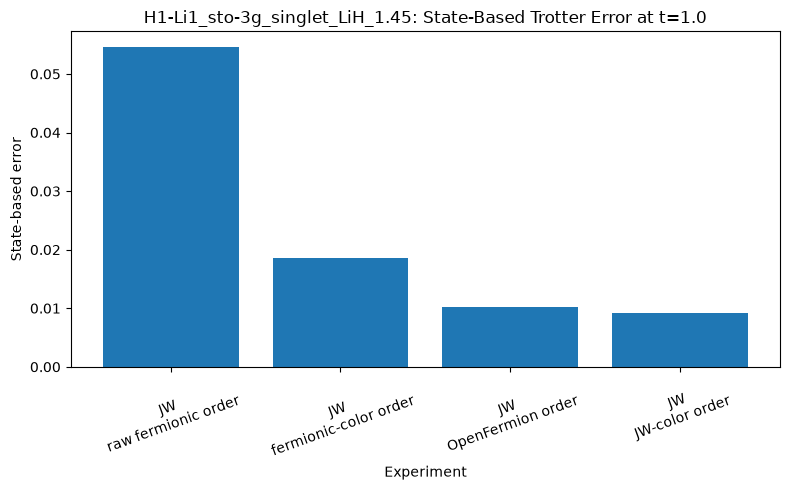


=== One-row molecular summary ===


,molecule,n_qubits,reference_electrons,fermionic_graph_vertices,fermionic_possible_pairs,fermionic_noncommuting_edges,fermionic_graph_density,fermionic_greedy_colors,fermionic_color_group_sizes,jw_pauli_graph_vertices,...,jw_fermionic_color_order_number_of_exponentials,jw_fermionic_color_order_runtime_seconds,jw_openfermion_order_state_based_error,jw_openfermion_order_state_infidelity,jw_openfermion_order_number_of_exponentials,jw_openfermion_order_runtime_seconds,jw_jw_color_order_state_based_error,jw_jw_color_order_state_infidelity,jw_jw_color_order_number_of_exponentials,jw_jw_color_order_runtime_seconds
0,H1-Li1_sto-3g_singlet_LiH_1.45,6,2,41,820,376,0.458537,7,"[7, 7, 5, 5, 3, 7, 7]",61,...,42,0.02535,0.010171,0.000103,62,0.0175,0.009212,0.000085,62,0.015581



=== Structural interpretation ===
JW vertex expansion factor: 1.488
JW candidate-pair expansion factor: 2.232
JW greedy-color expansion factor: 0.857
JW Pauli-duplication ratio: 2.738
Result: the fermionic representation gives a smaller graph-search space than the JW Pauli representation.
The greedy color count does not show a clear fermionic advantage for this molecule.

=== Results saved successfully ===
Output folder: /Users/a_lee/Repos/qhat/fermionic_trotter_results/H1-Li1_sto-3g_singlet_LiH_1.45
Saved: H1-Li1_sto-3g_singlet_LiH_1.45_fermionic_state_errors.csv
Saved: H1-Li1_sto-3g_singlet_LiH_1.45_fermionic_state_summary.csv
Saved: H1-Li1_sto-3g_singlet_LiH_1.45_graph_structure_comparison.csv
Saved: H1-Li1_sto-3g_singlet_LiH_1.45_structural_advantage.csv


2414

In [41]:
# New Cell 6:
# Final state-error results and structural comparison between
# the fermionic-term graph and the JW Pauli-string graph.
#
# The JW graph is analyzed without constructing a NetworkX graph.

import gc
import math
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Settings
# ============================================================

FIXED_TIME = 1.0

# Largest-first greedy coloring is useful for comparing the number
# of fermionic groups with the number of JW Pauli groups.
COMPUTE_GREEDY_PAULI_COLORING = True

# Larger blocks use more memory but usually reduce Python overhead.
PAULI_PAIR_BLOCK_SIZE = 512

# The main comparison is fermionic terms versus JW Pauli strings.
# Set this to True only when you also want to verify the BK graph.
COMPUTE_BK_GRAPH_STATISTICS = False


# ============================================================
# Binary symplectic representation of Pauli strings
# ============================================================

def qubit_operator_to_symplectic_masks(
    qubit_operator,
    n_qubits,
    exclude_identity=True,
    atol=1.0e-12,
):
    """
    Convert each unique Pauli string into two uint64 masks.

    X-mask:
        bit q is 1 when the string has X or Y on qubit q.

    Z-mask:
        bit q is 1 when the string has Z or Y on qubit q.

    Two Pauli strings anticommute when

        parity(x1 & z2) XOR parity(z1 & x2) = 1.

    This implementation supports up to 63 qubits.
    """
    if n_qubits > 63:
        raise ValueError(
            "This fast uint64 implementation supports at most 63 qubits."
        )

    x_masks = []
    z_masks = []

    for pauli_term, coefficient in qubit_operator.terms.items():
        if abs(coefficient) <= atol:
            continue

        if exclude_identity and pauli_term == ():
            continue

        x_mask = np.uint64(0)
        z_mask = np.uint64(0)

        for qubit, pauli in pauli_term:
            bit = np.uint64(1) << np.uint64(qubit)

            if pauli == "X":
                x_mask |= bit

            elif pauli == "Y":
                x_mask |= bit
                z_mask |= bit

            elif pauli == "Z":
                z_mask |= bit

            else:
                raise ValueError(
                    f"Unknown Pauli symbol {pauli!r}."
                )

        x_masks.append(x_mask)
        z_masks.append(z_mask)

    return (
        np.asarray(x_masks, dtype=np.uint64),
        np.asarray(z_masks, dtype=np.uint64),
    )


def parity_uint64(values):
    """
    Calculate the bit-count parity of uint64 values.

    Returns 1 for odd parity and 0 for even parity.
    """
    values = np.asarray(values, dtype=np.uint64).copy()

    values ^= values >> np.uint64(32)
    values ^= values >> np.uint64(16)
    values ^= values >> np.uint64(8)
    values ^= values >> np.uint64(4)
    values ^= values >> np.uint64(2)
    values ^= values >> np.uint64(1)

    return values & np.uint64(1)


def pauli_anticommutation_block(
    x_left,
    z_left,
    x_right,
    z_right,
):
    """
    Return a Boolean matrix whose (i, j) entry is True when
    Pauli string i anticommutes with Pauli string j.
    """
    symplectic_products = np.bitwise_xor(
        np.bitwise_and(
            x_left[:, None],
            z_right[None, :],
        ),
        np.bitwise_and(
            z_left[:, None],
            x_right[None, :],
        ),
    )

    return parity_uint64(symplectic_products).astype(bool)


# ============================================================
# Exact graph statistics without NetworkX
# ============================================================

def calculate_pauli_graph_degrees_and_edges(
    x_masks,
    z_masks,
    block_size=512,
):
    """
    Calculate exact degrees and exact noncommuting-edge count
    without constructing a graph object or full adjacency matrix.

    Time complexity is still O(M^2), where M is the number of
    unique nonidentity Pauli strings.
    """
    number_of_vertices = len(x_masks)

    degrees = np.zeros(
        number_of_vertices,
        dtype=np.int64,
    )

    number_of_edges = 0

    if number_of_vertices <= 1:
        return degrees, number_of_edges

    for left_start in range(
        0,
        number_of_vertices,
        block_size,
    ):
        left_stop = min(
            left_start + block_size,
            number_of_vertices,
        )

        x_left = x_masks[left_start:left_stop]
        z_left = z_masks[left_start:left_stop]

        for right_start in range(
            left_start,
            number_of_vertices,
            block_size,
        ):
            right_stop = min(
                right_start + block_size,
                number_of_vertices,
            )

            x_right = x_masks[right_start:right_stop]
            z_right = z_masks[right_start:right_stop]

            anticommutes = pauli_anticommutation_block(
                x_left=x_left,
                z_left=z_left,
                x_right=x_right,
                z_right=z_right,
            )

            if left_start == right_start:
                # A Pauli string commutes with itself.
                np.fill_diagonal(anticommutes, False)

                block_degrees = anticommutes.sum(
                    axis=1,
                    dtype=np.int64,
                )

                degrees[
                    left_start:left_stop
                ] += block_degrees

                # The symmetric block counts every edge twice.
                number_of_edges += (
                    int(anticommutes.sum()) // 2
                )

            else:
                degrees[
                    left_start:left_stop
                ] += anticommutes.sum(
                    axis=1,
                    dtype=np.int64,
                )

                degrees[
                    right_start:right_stop
                ] += anticommutes.sum(
                    axis=0,
                    dtype=np.int64,
                )

                # A cross-block edge appears only once.
                number_of_edges += int(
                    anticommutes.sum()
                )

        print(
            "  Pair analysis:"
            f" {left_stop}/{number_of_vertices}"
            " Pauli strings processed"
        )

    return degrees, number_of_edges


# ============================================================
# Largest-first greedy coloring without NetworkX
# ============================================================

def greedy_largest_first_pauli_coloring(
    x_masks,
    z_masks,
    degrees,
):
    """
    Apply deterministic largest-degree-first greedy coloring.

    This gives a valid coloring and an upper bound on the
    chromatic number. It is not an exact minimum coloring.
    """
    number_of_vertices = len(x_masks)

    if number_of_vertices == 0:
        return (
            np.array([], dtype=int),
            [],
        )

    vertex_indices = np.arange(
        number_of_vertices,
        dtype=int,
    )

    # Primary key: decreasing degree.
    # Secondary key: increasing original index.
    coloring_order = np.lexsort(
        (
            vertex_indices,
            -degrees,
        )
    )

    colors = np.full(
        number_of_vertices,
        -1,
        dtype=int,
    )

    largest_color = -1

    for position, vertex in enumerate(coloring_order):
        if position == 0:
            colors[vertex] = 0
            largest_color = 0
            continue

        previous_vertices = coloring_order[:position]

        symplectic_products = np.bitwise_xor(
            np.bitwise_and(
                x_masks[vertex],
                z_masks[previous_vertices],
            ),
            np.bitwise_and(
                z_masks[vertex],
                x_masks[previous_vertices],
            ),
        )

        anticommutes = parity_uint64(
            symplectic_products
        ).astype(bool)

        forbidden_colors = colors[
            previous_vertices[anticommutes]
        ]

        # Add one extra slot so that a new color is always available.
        used = np.zeros(
            largest_color + 2,
            dtype=bool,
        )

        if len(forbidden_colors) > 0:
            used[forbidden_colors] = True

        available_colors = np.flatnonzero(~used)
        chosen_color = int(available_colors[0])

        colors[vertex] = chosen_color
        largest_color = max(
            largest_color,
            chosen_color,
        )

        if (
            (position + 1) % 1000 == 0
            or position + 1 == number_of_vertices
        ):
            print(
                "  Coloring:"
                f" {position + 1}/{number_of_vertices}"
                " Pauli strings processed"
            )

    color_group_sizes = np.bincount(
        colors,
        minlength=largest_color + 1,
    ).tolist()

    return colors, color_group_sizes


def calculate_pauli_graph_statistics(
    qubit_operator,
    n_qubits,
    mapping_label,
    block_size=512,
    compute_coloring=True,
):
    """
    Calculate Pauli noncommutation-graph statistics without NetworkX.
    """
    total_start = time.perf_counter()

    x_masks, z_masks = qubit_operator_to_symplectic_masks(
        qubit_operator=qubit_operator,
        n_qubits=n_qubits,
        exclude_identity=True,
    )

    number_of_vertices = len(x_masks)
    number_of_possible_pairs = (
        number_of_vertices
        * (number_of_vertices - 1)
        // 2
    )

    print()
    print(
        f"=== Calculating {mapping_label} Pauli graph ==="
    )
    print(
        "Unique nonidentity Pauli strings:",
        number_of_vertices,
    )
    print(
        "Possible unordered pairs:",
        number_of_possible_pairs,
    )

    pair_start = time.perf_counter()

    degrees, number_of_edges = (
        calculate_pauli_graph_degrees_and_edges(
            x_masks=x_masks,
            z_masks=z_masks,
            block_size=block_size,
        )
    )

    pair_runtime = time.perf_counter() - pair_start

    if number_of_possible_pairs > 0:
        graph_density = (
            number_of_edges
            / number_of_possible_pairs
        )
    else:
        graph_density = 0.0

    if number_of_vertices > 0:
        average_degree = float(
            degrees.mean()
        )
        maximum_degree = int(
            degrees.max()
        )
    else:
        average_degree = 0.0
        maximum_degree = 0

    if compute_coloring:
        coloring_start = time.perf_counter()

        colors, color_group_sizes = (
            greedy_largest_first_pauli_coloring(
                x_masks=x_masks,
                z_masks=z_masks,
                degrees=degrees,
            )
        )

        coloring_runtime = (
            time.perf_counter()
            - coloring_start
        )

        number_of_colors = (
            int(colors.max()) + 1
            if len(colors) > 0
            else 0
        )

    else:
        coloring_runtime = np.nan
        number_of_colors = np.nan
        color_group_sizes = []

    total_runtime = time.perf_counter() - total_start

    return {
        "representation": f"{mapping_label} Pauli strings",
        "number_of_vertices": number_of_vertices,
        "number_of_possible_pairs": number_of_possible_pairs,
        "number_of_noncommuting_edges": number_of_edges,
        "graph_density": graph_density,
        "average_degree": average_degree,
        "maximum_degree": maximum_degree,
        "largest_first_greedy_colors": number_of_colors,
        "color_group_sizes": str(color_group_sizes),
        "pair_analysis_runtime_seconds": pair_runtime,
        "coloring_runtime_seconds": coloring_runtime,
        "total_graph_runtime_seconds": total_runtime,
    }


# ============================================================
# Fermionic graph statistics
# ============================================================

def is_identity_fermion_operator(operator, atol=1.0e-12):
    """
    Return True when the operator contains only an identity term.
    """
    surviving_terms = [
        term
        for term, coefficient in operator.terms.items()
        if abs(coefficient) > atol
    ]

    return (
        len(surviving_terms) == 1
        and surviving_terms[0] == ()
    )


def get_graph_fermionic_operator(node):
    """
    Recover the FermionOperator stored at a graph node.
    """
    if "operator" in G.nodes[node]:
        return G.nodes[node]["operator"]

    return hermitian_terms[node]


fermionic_nonidentity_nodes = [
    node
    for node in G.nodes
    if not is_identity_fermion_operator(
        get_graph_fermionic_operator(node)
    )
]

fermionic_number_of_vertices = len(
    fermionic_nonidentity_nodes
)

fermionic_number_of_possible_pairs = (
    fermionic_number_of_vertices
    * (fermionic_number_of_vertices - 1)
    // 2
)

# Removing the identity does not remove any noncommuting edges.
fermionic_number_of_edges = G.number_of_edges()

if fermionic_number_of_possible_pairs > 0:
    fermionic_graph_density = (
        fermionic_number_of_edges
        / fermionic_number_of_possible_pairs
    )
else:
    fermionic_graph_density = 0.0


# Color-group sizes after excluding the identity term.
fermionic_color_group_sizes = []

for color in sorted(color_groups):
    nonidentity_count = sum(
        not is_identity_fermion_operator(
            get_graph_fermionic_operator(node)
        )
        for node in color_groups[color]
    )

    if nonidentity_count > 0:
        fermionic_color_group_sizes.append(
            nonidentity_count
        )

fermionic_number_of_colors = len(
    fermionic_color_group_sizes
)

fermionic_average_degree = (
    2.0
    * fermionic_number_of_edges
    / fermionic_number_of_vertices
    if fermionic_number_of_vertices > 0
    else 0.0
)


# ============================================================
# Calculate JW Pauli graph statistics
# ============================================================

jw_graph_statistics = calculate_pauli_graph_statistics(
    qubit_operator=H_JW,
    n_qubits=n_qubits,
    mapping_label="JW",
    block_size=PAULI_PAIR_BLOCK_SIZE,
    compute_coloring=COMPUTE_GREEDY_PAULI_COLORING,
)


# BK is optional because the JW and BK analyses approximately
# double the graph-statistics runtime.
bk_graph_statistics = None

if COMPUTE_BK_GRAPH_STATISTICS:
    bk_graph_statistics = calculate_pauli_graph_statistics(
        qubit_operator=H_BK,
        n_qubits=n_qubits,
        mapping_label="BK",
        block_size=PAULI_PAIR_BLOCK_SIZE,
        compute_coloring=COMPUTE_GREEDY_PAULI_COLORING,
    )


# ============================================================
# Graph-structure comparison table
# ============================================================

fermionic_graph_statistics = {
    "representation": "Hermitian fermionic terms",
    "number_of_vertices": fermionic_number_of_vertices,
    "number_of_possible_pairs": (
        fermionic_number_of_possible_pairs
    ),
    "number_of_noncommuting_edges": (
        fermionic_number_of_edges
    ),
    "graph_density": fermionic_graph_density,
    "average_degree": fermionic_average_degree,
    "maximum_degree": np.nan,
    "largest_first_greedy_colors": (
        fermionic_number_of_colors
    ),
    "color_group_sizes": str(
        fermionic_color_group_sizes
    ),
    "pair_analysis_runtime_seconds": np.nan,
    "coloring_runtime_seconds": np.nan,
    "total_graph_runtime_seconds": np.nan,
}

graph_rows = [
    fermionic_graph_statistics,
    jw_graph_statistics,
]

if bk_graph_statistics is not None:
    graph_rows.append(bk_graph_statistics)

graph_structure_comparison_df = pd.DataFrame(
    graph_rows
)

print()
print("=== Noncommutation graph structure comparison ===")

display(
    graph_structure_comparison_df[
        [
            "representation",
            "number_of_vertices",
            "number_of_possible_pairs",
            "number_of_noncommuting_edges",
            "graph_density",
            "average_degree",
            "largest_first_greedy_colors",
            "color_group_sizes",
            "total_graph_runtime_seconds",
        ]
    ]
)


# ============================================================
# JW Pauli expansion and duplication statistics
# ============================================================

def count_nonidentity_pauli_terms(qubit_operator):
    return sum(
        1
        for pauli_term, coefficient
        in qubit_operator.terms.items()
        if (
            pauli_term != ()
            and abs(coefficient) > 1.0e-12
        )
    )


# Number of Pauli strings before combining duplicates generated
# by different fermionic terms.
jw_uncombined_nonidentity_count = sum(
    count_nonidentity_pauli_terms(mapped_term)
    for mapped_term in JW_fermionic_term_order
)

# Number of unique Pauli strings after combining the full Hamiltonian.
jw_unique_nonidentity_count = (
    jw_graph_statistics["number_of_vertices"]
)

if jw_unique_nonidentity_count > 0:
    jw_pauli_duplication_ratio = (
        jw_uncombined_nonidentity_count
        / jw_unique_nonidentity_count
    )
else:
    jw_pauli_duplication_ratio = np.nan


# ============================================================
# Structural-advantage metrics
# ============================================================

def safe_ratio(numerator, denominator):
    if denominator == 0:
        return np.nan

    return numerator / denominator


vertex_expansion_factor = safe_ratio(
    jw_graph_statistics["number_of_vertices"],
    fermionic_number_of_vertices,
)

pair_search_expansion_factor = safe_ratio(
    jw_graph_statistics["number_of_possible_pairs"],
    fermionic_number_of_possible_pairs,
)

edge_expansion_factor = safe_ratio(
    jw_graph_statistics[
        "number_of_noncommuting_edges"
    ],
    fermionic_number_of_edges,
)

color_expansion_factor = safe_ratio(
    jw_graph_statistics[
        "largest_first_greedy_colors"
    ],
    fermionic_number_of_colors,
)

pair_search_reduction_fraction = (
    1.0
    - safe_ratio(
        fermionic_number_of_possible_pairs,
        jw_graph_statistics[
            "number_of_possible_pairs"
        ],
    )
)

structural_advantage_df = pd.DataFrame(
    [
        {
            "molecule": MOLECULE_LABEL,
            "fermionic_graph_vertices": (
                fermionic_number_of_vertices
            ),
            "jw_pauli_graph_vertices": (
                jw_graph_statistics[
                    "number_of_vertices"
                ]
            ),
            "jw_vertex_expansion_factor": (
                vertex_expansion_factor
            ),
            "fermionic_candidate_pairs": (
                fermionic_number_of_possible_pairs
            ),
            "jw_candidate_pairs": (
                jw_graph_statistics[
                    "number_of_possible_pairs"
                ]
            ),
            "jw_pair_search_expansion_factor": (
                pair_search_expansion_factor
            ),
            "fermionic_noncommuting_edges": (
                fermionic_number_of_edges
            ),
            "jw_noncommuting_edges": (
                jw_graph_statistics[
                    "number_of_noncommuting_edges"
                ]
            ),
            "jw_edge_expansion_factor": (
                edge_expansion_factor
            ),
            "fermionic_greedy_colors": (
                fermionic_number_of_colors
            ),
            "jw_greedy_colors": (
                jw_graph_statistics[
                    "largest_first_greedy_colors"
                ]
            ),
            "jw_color_expansion_factor": (
                color_expansion_factor
            ),
            "pair_search_reduction_using_fermions": (
                pair_search_reduction_fraction
            ),
            "jw_uncombined_pauli_strings": (
                jw_uncombined_nonidentity_count
            ),
            "jw_unique_pauli_strings": (
                jw_unique_nonidentity_count
            ),
            "jw_pauli_duplication_ratio": (
                jw_pauli_duplication_ratio
            ),
        }
    ]
)

print()
print("=== Fermionic structural-advantage metrics ===")
display(structural_advantage_df)


# ============================================================
# Fixed-time state-based error table
# ============================================================

fixed_time_df = fermionic_state_error_df[
    np.isclose(
        fermionic_state_error_df["time_t"],
        FIXED_TIME,
    )
].copy()

if fixed_time_df.empty:
    available_times = sorted(
        fermionic_state_error_df[
            "time_t"
        ].unique()
    )

    FIXED_TIME = available_times[-1]

    fixed_time_df = fermionic_state_error_df[
        np.isclose(
            fermionic_state_error_df["time_t"],
            FIXED_TIME,
        )
    ].copy()


print()
print(
    f"=== State-based Trotter error at t = "
    f"{FIXED_TIME} ==="
)

display(
    fixed_time_df[
        [
            "mapping",
            "ordering",
            "number_of_exponentials",
            "state_based_error",
            "state_infidelity",
            "trotter_runtime_seconds",
        ]
    ].sort_values(
        [
            "mapping",
            "ordering",
        ]
    )
)


# ============================================================
# State-error plot
# ============================================================

plt.figure(figsize=(8, 5))

if fermionic_state_error_df["time_t"].nunique() > 1:
    for (
        mapping,
        ordering,
    ), group in fermionic_state_error_df.groupby(
        [
            "mapping",
            "ordering",
        ]
    ):
        group = group.sort_values("time_t")

        plt.plot(
            group["time_t"],
            group["state_based_error"],
            marker="o",
            label=f"{mapping}, {ordering}",
        )

    plt.xlabel("Time t")
    plt.ylabel("State-based error")
    plt.title(
        f"{MOLECULE_LABEL}: "
        "State-Based Trotter Error vs Time"
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

else:
    plotting_df = fixed_time_df.copy()

    plotting_df["experiment"] = (
        plotting_df["mapping"]
        + "\n"
        + plotting_df["ordering"]
    )

    plt.bar(
        plotting_df["experiment"],
        plotting_df["state_based_error"],
    )

    plt.xlabel("Experiment")
    plt.ylabel("State-based error")
    plt.title(
        f"{MOLECULE_LABEL}: "
        f"State-Based Trotter Error at "
        f"t={FIXED_TIME}"
    )
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


# ============================================================
# One-row molecular summary
# ============================================================

summary_row = {
    "molecule": MOLECULE_LABEL,
    "n_qubits": n_qubits,
    "reference_electrons": n_reference_electrons,

    # Fermionic graph
    "fermionic_graph_vertices": (
        fermionic_number_of_vertices
    ),
    "fermionic_possible_pairs": (
        fermionic_number_of_possible_pairs
    ),
    "fermionic_noncommuting_edges": (
        fermionic_number_of_edges
    ),
    "fermionic_graph_density": (
        fermionic_graph_density
    ),
    "fermionic_greedy_colors": (
        fermionic_number_of_colors
    ),
    "fermionic_color_group_sizes": str(
        fermionic_color_group_sizes
    ),

    # JW Pauli graph
    "jw_pauli_graph_vertices": (
        jw_graph_statistics[
            "number_of_vertices"
        ]
    ),
    "jw_pauli_possible_pairs": (
        jw_graph_statistics[
            "number_of_possible_pairs"
        ]
    ),
    "jw_pauli_noncommuting_edges": (
        jw_graph_statistics[
            "number_of_noncommuting_edges"
        ]
    ),
    "jw_pauli_graph_density": (
        jw_graph_statistics[
            "graph_density"
        ]
    ),
    "jw_pauli_greedy_colors": (
        jw_graph_statistics[
            "largest_first_greedy_colors"
        ]
    ),
    "jw_pauli_color_group_sizes": (
        jw_graph_statistics[
            "color_group_sizes"
        ]
    ),

    # Structural advantage
    "jw_vertex_expansion_factor": (
        vertex_expansion_factor
    ),
    "jw_pair_search_expansion_factor": (
        pair_search_expansion_factor
    ),
    "jw_edge_expansion_factor": (
        edge_expansion_factor
    ),
    "jw_color_expansion_factor": (
        color_expansion_factor
    ),
    "pair_search_reduction_using_fermions": (
        pair_search_reduction_fraction
    ),
    "jw_pauli_duplication_ratio": (
        jw_pauli_duplication_ratio
    ),

    # Experiment settings
    "fixed_time_t": FIXED_TIME,
    "trotter_steps": N_TROTTER_STEPS,
}


for _, row in fixed_time_df.iterrows():
    mapping_tag = row["mapping"].lower()

    ordering_tag = (
        row["ordering"]
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

    prefix = (
        f"{mapping_tag}_{ordering_tag}"
    )

    summary_row[
        f"{prefix}_state_based_error"
    ] = row["state_based_error"]

    summary_row[
        f"{prefix}_state_infidelity"
    ] = row["state_infidelity"]

    summary_row[
        f"{prefix}_number_of_exponentials"
    ] = row["number_of_exponentials"]

    summary_row[
        f"{prefix}_runtime_seconds"
    ] = row["trotter_runtime_seconds"]


molecule_state_summary_df = pd.DataFrame(
    [summary_row]
)

print()
print("=== One-row molecular summary ===")
display(molecule_state_summary_df)


# ============================================================
# Simple structural interpretation
# ============================================================

print()
print("=== Structural interpretation ===")

print(
    "JW vertex expansion factor:",
    f"{vertex_expansion_factor:.3f}"
)

print(
    "JW candidate-pair expansion factor:",
    f"{pair_search_expansion_factor:.3f}"
)

print(
    "JW greedy-color expansion factor:",
    f"{color_expansion_factor:.3f}"
)

print(
    "JW Pauli-duplication ratio:",
    f"{jw_pauli_duplication_ratio:.3f}"
)

if (
    vertex_expansion_factor > 1.0
    and pair_search_expansion_factor > 1.0
):
    print(
        "Result: the fermionic representation gives a "
        "smaller graph-search space than the JW Pauli "
        "representation."
    )
else:
    print(
        "Result: this molecule does not show a clear "
        "fermionic graph-size advantage."
    )

if (
    COMPUTE_GREEDY_PAULI_COLORING
    and color_expansion_factor > 1.0
):
    print(
        "The JW Pauli graph also requires more greedy "
        "color groups than the fermionic graph."
    )
elif COMPUTE_GREEDY_PAULI_COLORING:
    print(
        "The greedy color count does not show a clear "
        "fermionic advantage for this molecule."
    )


# ============================================================
# Export results into an organized molecule folder
# ============================================================

from pathlib import Path


safe_molecule_label = re.sub(
    r"[^A-Za-z0-9_.-]+",
    "_",
    MOLECULE_LABEL,
).strip("_")

if not safe_molecule_label:
    safe_molecule_label = "molecule"


# Main folder for all eleven molecular experiments
output_root = Path("fermionic_trotter_results")

# Separate folder for the current molecule
output_folder = output_root / safe_molecule_label

output_folder.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Output filenames
# ------------------------------------------------------------

time_output_file = (
    output_folder
    / f"{safe_molecule_label}_fermionic_state_errors.csv"
)

summary_output_file = (
    output_folder
    / f"{safe_molecule_label}_fermionic_state_summary.csv"
)

graph_output_file = (
    output_folder
    / f"{safe_molecule_label}_graph_structure_comparison.csv"
)

advantage_output_file = (
    output_folder
    / f"{safe_molecule_label}_structural_advantage.csv"
)


# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------

fermionic_state_error_df.to_csv(
    time_output_file,
    index=False,
)

molecule_state_summary_df.to_csv(
    summary_output_file,
    index=False,
)

graph_structure_comparison_df.to_csv(
    graph_output_file,
    index=False,
)

structural_advantage_df.to_csv(
    advantage_output_file,
    index=False,
)


print()
print("=== Results saved successfully ===")
print("Output folder:", output_folder.resolve())
print("Saved:", time_output_file.name)
print("Saved:", summary_output_file.name)
print("Saved:", graph_output_file.name)
print("Saved:", advantage_output_file.name)

gc.collect()

# LiH Structural Comparison: Fermionic Terms vs. JW Pauli Strings

## Purpose

This notebook compares two representations of the LiH molecular Hamiltonian:

1. Hermitian fermionic terms before qubit mapping
2. Unique Pauli strings after the Jordan–Wigner transformation

The objective is to determine whether constructing and coloring the noncommutation graph at the fermionic level produces a smaller classical graph problem and whether the resulting ordering affects the Trotter error.

---

## Current LiH Active-Space Configuration

For the active-space calculation used in this notebook:

- LiH has four total electrons.
- One occupied spatial orbital is frozen.
- The active space contains three spatial orbitals.
- Three spatial orbitals correspond to six spin orbitals and therefore six qubits.
- Freezing one doubly occupied spatial orbital leaves two active electrons.
- The Hartree–Fock reference state therefore contains two occupied active spin orbitals.

Thus,

$$
n_{\mathrm{qubits}} = 6
$$

and

$$
n_{\mathrm{active\ electrons}} = 2.
$$

These values must be updated if the active-space configuration changes.

---

## Fermionic Hamiltonian Decomposition

The fermionic Hamiltonian is decomposed as

$$
H_f
=
\sum_{\alpha=1}^{M_F} H_{\alpha},
$$

where each $H_{\alpha}$ is a Hermitian fermionic term.

A noncommutation graph is constructed with:

- one vertex for each nonidentity Hermitian fermionic term;
- one edge between vertices $\alpha$ and $\beta$ when

$$
[H_{\alpha},H_{\beta}] \neq 0.
$$

Terms assigned to the same valid color group commute with one another.

---

## Jordan–Wigner Pauli Decomposition

After the Jordan–Wigner transformation, the Hamiltonian is written as

$$
H_{\mathrm{JW}}
=
\sum_{j=1}^{M_{\mathrm{JW}}}
c_j P_j,
$$

where each $P_j$ is a unique Pauli string.

The JW Pauli noncommutation graph contains:

- one vertex for each unique nonidentity Pauli string;
- one edge between $P_i$ and $P_j$ when

$$
[P_i,P_j] \neq 0.
$$

---

## Structural Quantities

Let

- $V_F$ be the number of nonidentity Hermitian fermionic terms,
- $V_{\mathrm{JW}}$ be the number of unique nonidentity JW Pauli strings,
- $E_F$ be the number of noncommuting fermionic-term pairs,
- $E_{\mathrm{JW}}$ be the number of noncommuting JW Pauli-string pairs,
- $C_F$ be the number of greedy colors for the fermionic graph,
- $C_{\mathrm{JW}}$ be the number of greedy colors for the JW graph.

---

### Candidate-Pair Counts

For a graph with $V$ vertices, the number of possible unordered pairs is

$$
P(V)
=
\binom{V}{2}
=
\frac{V(V-1)}{2}.
$$

Therefore,

$$
P_F
=
\binom{V_F}{2}
$$

and

$$
P_{\mathrm{JW}}
=
\binom{V_{\mathrm{JW}}}{2}.
$$

These quantities measure the maximum number of pairwise commutation tests needed to construct each graph.

---

### JW Vertex-Expansion Factor

The increase in graph size after JW mapping is measured by

$$
R_V
=
\frac{V_{\mathrm{JW}}}{V_F}.
$$

Interpretation:

- $R_V>1$: the JW Pauli graph contains more vertices.
- $R_V=1$: both graphs contain the same number of vertices.
- $R_V<1$: the JW Pauli graph contains fewer vertices.

---

### JW Candidate-Pair Expansion Factor

The increase in possible pairwise commutation tests is

$$
R_P
=
\frac{P_{\mathrm{JW}}}{P_F}
=
\frac{\binom{V_{\mathrm{JW}}}{2}}
     {\binom{V_F}{2}}.
$$

Equivalently,

$$
R_P
=
\frac{
V_{\mathrm{JW}}(V_{\mathrm{JW}}-1)
}{
V_F(V_F-1)
}.
$$

For sufficiently large graphs,

$$
R_P
\approx
R_V^2.
$$

Therefore, even a moderate increase in the number of JW vertices can produce a much larger increase in the number of candidate pairs.

---

### Pair-Search Reduction from Using Fermionic Terms

The fractional reduction in candidate-pair tests obtained by using the fermionic graph is

$$
S_P
=
1-
\frac{P_F}{P_{\mathrm{JW}}}.
$$

The percentage reduction is

$$
100S_P\%.
$$

A positive value indicates that constructing the fermionic graph requires fewer candidate-pair checks.

---

### Noncommuting-Edge Expansion Factor

The increase in the number of actual noncommuting pairs is

$$
R_E
=
\frac{E_{\mathrm{JW}}}{E_F}.
$$

This compares actual graph edges rather than all possible vertex pairs.

---

### Graph Density

For a graph with $V$ vertices and $E$ edges, the graph density is

$$
D
=
\frac{E}{\binom{V}{2}}
=
\frac{2E}{V(V-1)}.
$$

Therefore,

$$
D_F
=
\frac{E_F}{\binom{V_F}{2}}
$$

and

$$
D_{\mathrm{JW}}
=
\frac{E_{\mathrm{JW}}}
     {\binom{V_{\mathrm{JW}}}{2}}.
$$

Graph density is the fraction of all possible term pairs that do not commute.

---

### Average Degree

The average degree of an undirected graph is

$$
\bar{d}
=
\frac{2E}{V}.
$$

Therefore,

$$
\bar{d}_F
=
\frac{2E_F}{V_F}
$$

and

$$
\bar{d}_{\mathrm{JW}}
=
\frac{2E_{\mathrm{JW}}}{V_{\mathrm{JW}}}.
$$

---

### Greedy-Color Expansion Factor

The relative number of greedy color groups is

$$
R_C
=
\frac{C_{\mathrm{JW}}}{C_F}.
$$

Interpretation:

- $R_C>1$: the JW graph requires more greedy color groups.
- $R_C=1$: both graphs use the same number of greedy colors.
- $R_C<1$: the JW graph uses fewer greedy colors.

The greedy color count is a heuristic upper bound and is not necessarily the exact chromatic number.

---

## JW Pauli-Duplication Ratio

Suppose that

$$
H_f
=
\sum_{\alpha} H_{\alpha}.
$$

Mapping each fermionic term separately can produce repeated Pauli strings.

Let

$$
N_{\mathrm{JW}}^{\mathrm{uncombined}}
=
\sum_{\alpha}
\#\mathrm{JW}(H_{\alpha})
$$

be the number of Pauli strings before combining duplicates.

Let

$$
N_{\mathrm{JW}}^{\mathrm{unique}}
=
\#\mathrm{JW}(H_f)
$$

be the number of unique Pauli strings in the complete mapped Hamiltonian.

The JW Pauli-duplication ratio is

$$
R_{\mathrm{dup}}
=
\frac{
N_{\mathrm{JW}}^{\mathrm{uncombined}}
}{
N_{\mathrm{JW}}^{\mathrm{unique}}
}
\geq 1.
$$

A larger value indicates that more Pauli strings are repeated across separately mapped fermionic terms.

---

## Trotter Experiments

The primary first-order Trotter experiments are:

1. Fermionic terms in raw order
2. Fermionic terms in fermionic-color order
3. Unique JW Pauli strings in OpenFermion order
4. Unique JW Pauli strings in JW-color order

For $r$ Trotter steps and total evolution time $t$, the first-order product formula is

$$
U_{\mathrm{Trotter}}^{(1)}(t,r)
=
\left[
\prod_{j=1}^{M}
e^{-i(t/r)H_j}
\right]^r.
$$

The second-order product formula is

$$
U_{\mathrm{Trotter}}^{(2)}(t,r)
=
\left[
\left(
\prod_{j=1}^{M}
e^{-i(t/2r)H_j}
\right)
\left(
\prod_{j=M}^{1}
e^{-i(t/2r)H_j}
\right)
\right]^r.
$$

The Suzuki formula order and the Hamiltonian term ordering are recorded separately.

---

## Hartree–Fock State-Based Error

The reference state for LiH is the active-space Hartree–Fock state

$$
|\psi_{\mathrm{HF}}\rangle.
$$

The exact evolved state is

$$
|\psi_{\mathrm{exact}}(t)\rangle
=
e^{-itH}
|\psi_{\mathrm{HF}}\rangle.
$$

The Trotter-evolved state is

$$
|\psi_{\mathrm{Trotter}}(t)\rangle
=
U_{\mathrm{Trotter}}(t)
|\psi_{\mathrm{HF}}\rangle.
$$

The state-based Trotter error is

$$
\epsilon_{\mathrm{state}}(t)
=
\left\|
|\psi_{\mathrm{Trotter}}(t)\rangle
-
|\psi_{\mathrm{exact}}(t)\rangle
\right\|_2.
$$

The phase-insensitive state infidelity is

$$
\epsilon_{\mathrm{infidelity}}(t)
=
1-
\left|
\langle
\psi_{\mathrm{exact}}(t)
|
\psi_{\mathrm{Trotter}}(t)
\rangle
\right|^2.
$$

The state-based error is a genuine Trotter error for the selected Hartree–Fock initial state, but it is not the worst-case error over all possible states.

---

## Operator-Norm Error

For sufficiently small active spaces, the state-independent operator-norm error is

$$
\epsilon_{\mathrm{op}}(t)
=
\left\|
U_{\mathrm{Trotter}}(t)
-
e^{-itH}
\right\|_2.
$$

This gives the largest possible error over normalized initial states:

$$
\epsilon_{\mathrm{op}}(t)
=
\max_{\|\psi\|_2=1}
\left\|
\left(
U_{\mathrm{Trotter}}(t)
-
e^{-itH}
\right)
|\psi\rangle
\right\|_2.
$$

For the six-qubit LiH active-space calculation, the dense operator-norm validation may still be feasible. For larger active spaces, only the matrix-free state-based calculation is retained.

---

## Interpretation of a Fermionic Structural Advantage

Evidence for a fermionic structural advantage is obtained when one or more of the following conditions hold:

$$
R_V>1,
\qquad
R_P>1,
\qquad
R_E>1,
\qquad
R_C>1.
$$

In particular,

$$
R_P>1
$$

shows that the fermionic representation has a smaller pairwise commutation-search space.

However, a smaller graph does not automatically imply a smaller Trotter error. Greedy coloring considers commutation structure but does not directly account for:

- Hamiltonian coefficient magnitudes,
- commutator norms,
- nested commutators,
- cancellations between neighboring terms,
- or the selected initial state.

Therefore, the structural graph metrics must be interpreted together with:

- state-based Trotter error,
- state infidelity,
- operator-norm error when feasible,
- number of primitive exponentials,
- and computational runtime.

---

## LiH Preliminary Conclusion

The LiH experiment is intended to determine whether the structural advantage observed at the fermionic level becomes more significant for a system larger than H2.

The main questions are:

1. Is the fermionic noncommutation graph smaller than the JW Pauli graph?
2. Does the fermionic graph require fewer greedy colors?
3. Does fermionic-color ordering reduce the Trotter error relative to raw fermionic ordering?
4. Does JW-color ordering reduce the Trotter error relative to the default JW Pauli ordering?
5. Does a smaller graph-search problem translate into a practical Trotterization advantage?

The numerical results below will be used to answer these questions for the current LiH geometry, basis, active space, threshold, total time, number of Trotter steps, and Suzuki formula order.